# AI-Based Churn Prediction and Explainable Analytics

## 6. Machine Learning Modelling Approach 

A range of supervised machine learning classification algorithms will be developed and evaluated to identify the most effective model for predicting customer churn within the PayStone fintech lending environment. The modelling approach begins with an interpretable baseline model and progresses towards advanced ensemble learning techniques to compare predictive performance, interpretability, and deployment suitability.

The following models will be implemented:

* **Logistic Regression**

  * Used as the baseline model due to its simplicity, transparency, and ability to estimate churn probability.
  * Provides an interpretable benchmark for understanding the relationship between customer characteristics and churn risk.


* **Random Forest**

  * Uses multiple decision trees to improve prediction accuracy and reduce overfitting.
  * Identifies important customer features influencing churn predictions.

* **XGBoost**

  * Advanced gradient boosting algorithm designed for high predictive performance on structured fintech datasets.
  * Effectively captures complex customer behaviour patterns and interactions.

* **LightGBM**

  * Efficient gradient boosting framework suitable for scalable customer analytics.
  * Provides fast training and strong predictive performance.

* **CatBoost**

  * Optimised for datasets containing categorical customer information.
  * Handles variables such as education level, income category, and card type effectively.

---

# 7. Model Evaluation Strategy (Summary)

All models will be evaluated using multiple classification metrics to ensure reliable performance assessment.

The evaluation framework includes:

* **Accuracy** – Measures overall prediction correctness.
* **Precision** – Evaluates how accurately churn customers are identified.
* **Recall** – Measures the ability to detect customers at risk of leaving.
* **F1-Score** – Provides a balance between precision and recall.
* **ROC-AUC Score** – Measures the model’s ability to distinguish between churn and retained customers.
* **Confusion Matrix** – Analyses correct and incorrect predictions.
* **Precision-Recall Curve** – Evaluates performance under potential class imbalance.
* **Stratified K-Fold Cross-Validation** – Ensures model robustness and generalisation.

### Hyperparameter Optimisation

Model performance will be improved using:

* **GridSearchCV** – Performs systematic parameter optimisation.
* **RandomizedSearchCV** – Efficiently searches a wider range of model configurations.

The final production model will be selected based on predictive performance, robustness, interpretability, computational efficiency, and suitability for deployment.

---

# 8. Explainable Artificial Intelligence (XAI) (Summary)

To ensure transparency and responsible AI adoption, the selected churn prediction model will be interpreted using **SHAP (SHapley Additive Explanations)**.

SHAP will be used to:

* Identify the most important factors influencing customer churn.
* Explain individual customer churn predictions.
* Highlight behavioural, financial, and demographic churn drivers.
* Improve trust and transparency among business stakeholders.

The explainability framework enables PayStone to understand **why customers are likely to churn**, allowing the organisation to implement targeted retention strategies and make informed customer management decisions.


# Import Require Data Science Libraries

In [15]:
# =============================================================================
# IMPORT CORE DATA SCIENCE LIBRARIES
# =============================================================================

# =============================================================================
# Data Analysis Packages
# ============================================================================
import pandas as pd        # Data manipulation and analysis
#import numpy as np         # Numerical computations
import numpy as np


# Data visualisation libraries
import matplotlib.pyplot as plt   # Create static charts
import seaborn as sns             # Statistical visualisations


# Operating system functions
import os                         # File and directory management

import math # mathematical computations


# Import Plotly libraries for interactive visualisations.

# Import Plotly Express for creating simple interactive charts
import plotly.express as px


# Import Plotly Graph Objects for advanced customised visualisations
import plotly.graph_objects as go


# Import subplot functionality for arranging multiple charts in a grid layout
from plotly.subplots import make_subplots

# =============================================================================
# REBUILD MATPLOTLIB FONT CACHE
# =============================================================================

# Import the main Matplotlib library.
# Matplotlib is used for creating static data visualisations,
# including line charts, bar charts, scatter plots, and confusion matrices.
import matplotlib

# Import the font manager module.
# The font manager is responsible for locating, loading,
# and managing fonts used in all Matplotlib figures.
import matplotlib.font_manager as fm
# Force Matplotlib to ignore the existing font cache (if present)
# and scan the system again for all available fonts.
#
# This can resolve font-related errors caused by:
# - Corrupted font cache
# - Missing font references
# - Newly installed fonts not being detected
#
# Note:
# This command rebuilds the font cache only.
# It will NOT repair missing Matplotlib font files.

fm._load_fontmanager(
    try_read_cache=False
)
# Display a confirmation message indicating that the
# font cache has been successfully refreshed.

print("Matplotlib font cache rebuilt successfully.")
# =======================================================================
# ML Modelling Packages
#========================================================================

from sklearn.preprocessing import StandardScaler # Import scaling tools for normalising and standardising numerical features
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets
from sklearn.model_selection import GridSearchCV      # For hyperparameter tuning

# Import the SMOTE (Synthetic Minority Over-sampling Technique) class from imblearn.over_sampling module
# SMOTE is used to address class imbalance by generating synthetic samples for minority classes
from imblearn.over_sampling import SMOTE

# Import StandardScaler for feature normalisation
from sklearn.preprocessing import StandardScaler
# Import classification models
from sklearn.linear_model import LogisticRegression           # Linear classifier
from sklearn.ensemble import RandomForestClassifier           # Ensemble method using multiple decision trees

from catboost import CatBoostClassifier  # Import the CatBoost classifier for supervised classification tasks.
                                         # CatBoost is a gradient boosting algorithm that handles categorical
                                         # features efficiently and often delivers high predictive performance.

from lightgbm import LGBMClassifier      # Import the LightGBM classifier for supervised classification tasks.
                                         # LightGBM is a fast, efficient gradient boosting algorithm that performs
                                         # well on large datasets and is widely used for classification problems.
from xgboost import XGBClassifier        # Gradient boosting implementation

# Import evaluation metrics
# For model performance evaluation
# For evaluating classification errors
# For ROC curve analysis
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
 


# Import all functions and classes from pycaret.classification module
# PyCaret is an open-source, low-code machine learning library in Python
# The classification module contains tools for classification tasks like:
# - Setting up experiment environments
# - Creating, comparing, and tuning classification models
# - Model evaluation, interpretation, and deployment
from pycaret.classification import *
from pycaret.classification import ClassificationExperiment
# Import the SHAP library for model interpretability and explainable AI (XAI).
# Import RandomizedSearchCV for efficient hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
#
# SHAP explains machine learning model predictions by measuring the contribution
# of each feature to an individual prediction.
#
# It helps identify:
# - Which customer features increase churn risk
# - Which features reduce churn probability
# - The overall importance of variables in the model
import shap
# Import joblib for saving and loading trained machine learning models.
# Joblib is particularly efficient for serialising Python objects such as
# trained Scikit-learn and machine learning models.
import joblib

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

import sys  # Import system module

print(sys.executable)  # Show the Python interpreter path currently used by the notebook


Matplotlib font cache rebuilt successfully.
C:\Users\EUGENE\anaconda3\envs\anaconda-nlp\python.exe


# Import Preprocessed Data From Working Directory

In [2]:
# =============================================================================
# LOAD PREPROCESSED DATASET
# =============================================================================


# Define the expected preprocessed dataset filename
file_name = "preprocessed_data.csv"

# Check whether the preprocessed dataset exists
if not os.path.exists(file_name):
    raise FileNotFoundError(
        f"{file_name} not found. Please ensure the preprocessed dataset is in the working directory."
    )

# Load the preprocessed dataset into a pandas DataFrame
df = pd.read_csv(file_name)

# Confirm successful loading
print("Preprocessed dataset loaded successfully.")

# Display dataset dimensions
print(f"Dataset shape: {df.shape}")

Preprocessed dataset loaded successfully.
Dataset shape: (10127, 26)


# Inspection of Data

In [3]:
# Display a concise summary of the DataFrame, including:
# - Number of rows and columns
# - Column names and data types
# - Count of non-null values in each column
# - Memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income_Category                  10127 non-null  float64
 1   Card_Category                    10127 non-null  float64
 2   Education_Level_Doctorate        10127 non-null  float64
 3   Education_Level_Graduate         10127 non-null  float64
 4   Education_Level_High School      10127 non-null  float64
 5   Education_Level_Post-Graduate    10127 non-null  float64
 6   Education_Level_Uneducated       10127 non-null  float64
 7   Education_Level_Unknown          10127 non-null  float64
 8   Marital_Status_Married           10127 non-null  float64
 9   Marital_Status_Single            10127 non-null  float64
 10  Marital_Status_Unknown           10127 non-null  float64
 11  Churn                            10127 non-null  float64
 12  Customer_Age                 

# Fix Target Class Imbalance Using SMOTE

In [4]:
# =============================================================================
# AUTOMATED DATA SPLITTING AND SMOTE PIPELINE
# =============================================================================

def prepare_ml_data(df, target_column="Churn", test_size=0.20, random_state=42):
    """
    Automated machine learning data preparation pipeline for classification tasks.

    This function prepares the dataset before model training by performing:
    
    1. Separation of predictor variables (features) and target variable.
    2. Splitting the dataset into training and testing subsets.
    3. Maintaining the original target class distribution using stratification.
    4. Checking the level of class imbalance in the training data.
    5. Applying SMOTE (Synthetic Minority Oversampling Technique) only to the
       training dataset to create a balanced training set.
    
    The test dataset is intentionally kept unchanged because it represents
    real-world unseen customer data and is used for unbiased model evaluation.

    Parameters:
    -----------
    df : pandas.DataFrame
        Preprocessed customer dataset containing predictor variables and target.

    target_column : str
        Name of the target variable to be predicted.
        For this project, the target variable is "Churn".

    test_size : float
        Percentage of data allocated for testing.
        Default value is 20% of the dataset.

    random_state : int
        Controls randomness during data splitting and SMOTE generation.
        Ensures that results can be reproduced.

    Returns:
    --------
    X_train_smote : pandas.DataFrame
        Balanced training feature dataset after applying SMOTE.

    X_test : pandas.DataFrame
        Original testing feature dataset containing unseen observations.

    y_train_smote : pandas.Series
        Balanced training target variable after synthetic oversampling.

    y_test : pandas.Series
        Original testing target variable used for final evaluation.
    """


    # =========================================================================
    # STEP 1: SEPARATE FEATURES AND TARGET VARIABLE
    # =========================================================================

    # Create the feature matrix (X).
    #
    # X contains all independent variables used by machine learning algorithms
    # to learn patterns associated with customer churn.
    #
    # Examples of features include:
    # - Customer demographics
    # - Account behaviour
    # - Transaction patterns
    # - Credit utilisation measures
    #
    # The target column is removed because it is the outcome we want the model
    # to predict.
    X = df.drop(target_column, axis=1)


    # Create the target variable (y).
    #
    # y represents the dependent variable that the model learns to predict.
    #
    # Churn encoding:
    # 0 = Existing Customer
    # 1 = Attrited Customer
    y = df[target_column]


    # =========================================================================
    # STEP 2: SPLIT DATA INTO TRAINING AND TESTING DATASETS
    # =========================================================================

    # Divide the dataset into:
    #
    # Training dataset:
    # - Used for model learning.
    # - Contains examples used to identify relationships between features and
    #   customer churn behaviour.
    #
    # Testing dataset:
    # - Contains unseen customer records.
    # - Used only after training to evaluate how well the model generalises.
    #
    # Stratified splitting is used because churn datasets are usually imbalanced.
    # It ensures both training and testing datasets maintain approximately the
    # same proportion of churned and non-churned customers.
    #
    # random_state ensures reproducibility, meaning the same split is generated
    # each time the pipeline is executed.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )


    # =========================================================================
    # STEP 3: CHECK ORIGINAL CLASS DISTRIBUTION
    # =========================================================================

    # Display the distribution of customer churn classes before applying SMOTE.
    #
    # This step identifies whether the target variable is imbalanced.
    #
    # In churn prediction, the majority class is often:
    # - Existing customers (0)
    #
    # while the minority class is:
    # - Customers who have churned (1)
    #
    # Class imbalance can cause models to favour the majority class and perform
    # poorly when identifying churn customers.
    print("Original Training Class Distribution:")
    print(y_train.value_counts())


    # =========================================================================
    # STEP 4: HANDLE CLASS IMBALANCE USING SMOTE
    # =========================================================================

    # Initialise SMOTE.
    #
    # SMOTE creates synthetic examples of the minority class by generating new
    # observations based on existing minority class patterns.
    #
    # This improves the model's ability to learn churn behaviour rather than
    # simply predicting the majority customer group.
    smote = SMOTE(random_state=random_state)


    # Apply SMOTE ONLY to the training dataset.
    #
    # Important:
    # The test dataset is NOT balanced because it must represent the original
    # customer population for realistic performance evaluation.
    #
    # Applying SMOTE before train-test splitting would cause data leakage and
    # produce overly optimistic model performance.
    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )


    # =========================================================================
    # STEP 5: VERIFY BALANCED DATASET
    # =========================================================================

    # Display the new target distribution after SMOTE.
    #
    # The minority class should now have increased representation, allowing
    # classification algorithms to learn both classes more effectively.
    print("\nBalanced Training Class Distribution:")
    print(y_train_smote.value_counts())


    # Display dataset dimensions after preprocessing.
    #
    # This confirms:
    # - Number of training observations increased after SMOTE.
    # - Number of features remains unchanged.
    # - Test data remains untouched.
    print("\nDataset Shapes:")
    print("X_train after SMOTE:", X_train_smote.shape)
    print("X_test:", X_test.shape)


    # =========================================================================
    # STEP 6: RETURN PROCESSED DATASETS FOR MODEL TRAINING
    # =========================================================================

    # Return the prepared datasets:
    #
    # X_train_smote, y_train_smote:
    # - Used for training machine learning models.
    #
    # X_test, y_test:
    # - Used for final model evaluation on unseen data.
    return X_train_smote, X_test, y_train_smote, y_test

In [5]:
# =============================================================================
# EXECUTE AUTOMATED PREPROCESSING PIPELINE
# =============================================================================

# Run the automated data preparation function:
# - Separates features (X) and target (y)
# - Splits data into training and testing sets
# - Applies SMOTE to balance the training data only
# - Returns datasets ready for machine learning modelling

X_train, X_test, y_train, y_test = prepare_ml_data(
    df,
    target_column="Churn"
)

Original Training Class Distribution:
Churn
0.0    6799
1.0    1302
Name: count, dtype: int64

Balanced Training Class Distribution:
Churn
0.0    6799
1.0    6799
Name: count, dtype: int64

Dataset Shapes:
X_train after SMOTE: (13598, 25)
X_test: (2026, 25)


# Machine Learning (ML) Modelling

### Apply Baseline ML Model- Logistic Regression Classifier

In [6]:
# =============================================================================
# LOGISTIC REGRESSION MODEL WITH FEATURE SCALING
# =============================================================================

# =============================================================================
# FEATURE SCALING
# =============================================================================

# Initialise StandardScaler to standardise numerical features.
# The scaler transforms features to have:
# Mean = 0
# Standard deviation = 1
scaler = StandardScaler()


# Fit scaler on the SMOTE-balanced training data and transform it.
# The scaler learns parameters only from training data to prevent data leakage.
X_train_scaled = scaler.fit_transform(X_train)


# Apply the same scaling transformation to the test data.
# The test data remains unseen during scaling.
X_test_scaled = scaler.transform(X_test)



# =============================================================================
# LOGISTIC REGRESSION MODEL
# =============================================================================

# Initialise Logistic Regression classifier.
#
# Parameters:
# - max_iter=1000:
#   Increases optimisation iterations to allow model convergence.
#
# - solver='liblinear':
#   Suitable for binary classification and smaller datasets.
#
# - C=1.0:
#   Controls regularisation strength.
#   Lower values apply stronger regularisation.
#
# - penalty='l2':
#   Applies Ridge regularisation to reduce overfitting.
#
# - random_state=42:
#   Ensures reproducible results.
#
log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)


# Train Logistic Regression using scaled training data
log_reg.fit(
    X_train_scaled,
    y_train
)


# Generate churn predictions on unseen test data
y_pred = log_reg.predict(
    X_test_scaled
)


# Generate churn probability predictions for ROC-AUC evaluation
y_prob = log_reg.predict_proba(
    X_test_scaled
)[:, 1]


# =============================================================================
# MODEL EVALUATION
# =============================================================================

# Display classification performance metrics:
# - Precision: Correct churn predictions
# - Recall: Ability to identify actual churn customers
# - F1-score: Balance between precision and recall
# - Support: Number of observations per class

print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.77      0.84      1701
         1.0       0.36      0.68      0.47       325

    accuracy                           0.76      2026
   macro avg       0.64      0.73      0.66      2026
weighted avg       0.84      0.76      0.78      2026



# Multiple Classification ML Models

In [7]:
# =============================================================================
# AUTOMATED ADVANCED MACHINE LEARNING MODELLING PIPELINE
# =============================================================================

def automated_ml_pipeline(X_train, X_test, y_train, y_test):
    """
    Complete automated machine learning classification pipeline.

    Performs:
    1. Defines ML models
    2. Trains models using SMOTE-balanced training data
    3. Generates predictions
    4. Calculates evaluation metrics
    5. Returns trained models and comparison results
    """

    # =========================================================================
    # DEFINE MACHINE LEARNING MODELS
    # =========================================================================

    # Create dictionary containing advanced ensemble classification models.
    # These models are suitable for customer churn prediction problems.

    models = {


        # =====================================================================
        # RANDOM FOREST CLASSIFIER
        # =====================================================================

        # Ensemble algorithm combining multiple decision trees.
        # Helps capture nonlinear customer behaviour patterns.

        "Random Forest": RandomForestClassifier(

            # Number of trees in the forest
            n_estimators=300,

            # Maximum depth of each decision tree
            max_depth=10,

            # Minimum samples required to split a node
            min_samples_split=5,

            # Minimum samples required at leaf nodes
            min_samples_leaf=2,

            # Ensures reproducible results
            random_state=42,

            # Uses all available processor cores
            n_jobs=-1
        ),



        # =====================================================================
        # XGBOOST CLASSIFIER
        # =====================================================================

        # Gradient boosting algorithm that sequentially improves predictions
        # by learning from previous model errors.

        "XGBoost": XGBClassifier(

            # Number of boosting trees
            n_estimators=300,

            # Controls contribution of each tree
            learning_rate=0.05,

            # Maximum depth of trees
            max_depth=5,

            # Percentage of observations used for each tree
            subsample=0.8,

            # Percentage of features used for each tree
            colsample_bytree=0.8,

            # Binary classification loss function
            eval_metric="logloss",

            # Ensures reproducibility
            random_state=42,

            # Uses all CPU cores
            n_jobs=-1
        ),



        # =====================================================================
        # LIGHTGBM CLASSIFIER
        # =====================================================================

        # Fast gradient boosting framework designed for high-performance
        # classification on structured/tabular datasets.

        "LightGBM": LGBMClassifier(

            # Number of boosting trees
            n_estimators=300,

            # Learning speed
            learning_rate=0.05,

            # Maximum tree depth
            max_depth=5,

            # Number of leaves per tree
            num_leaves=31,

            # Row sampling ratio
            subsample=0.8,

            # Feature sampling ratio
            colsample_bytree=0.8,

            # Ensures reproducibility
            random_state=42,

            # Uses all CPU cores
            n_jobs=-1
        ),



        # =====================================================================
        # CATBOOST CLASSIFIER
        # =====================================================================

        # Gradient boosting algorithm that performs well on customer analytics
        # and financial datasets.

        "CatBoost": CatBoostClassifier(

            # Number of boosting iterations
            iterations=300,

            # Learning rate
            learning_rate=0.05,

            # Maximum tree depth
            depth=6,

            # Binary classification objective function
            loss_function="Logloss",

            # Ensures reproducibility
            random_state=42,

            # Removes training output messages
            verbose=0
        )
    }



    # =========================================================================
    # INITIALISE STORAGE OBJECTS
    # =========================================================================

    # Store trained machine learning models
    trained_models = {}


    # Store evaluation results
    results = []



    # =========================================================================
    # TRAIN AND EVALUATE MODELS
    # =========================================================================

    # Loop through each machine learning algorithm

    for name, model in models.items():


        # Display current model training progress
        print(f"Training {name}...")


        # Train model using SMOTE-balanced training dataset
        model.fit(
            X_train,
            y_train
        )


        # Save trained model
        trained_models[name] = model



        # =====================================================================
        # MODEL PREDICTION
        # =====================================================================

        # Predict customer churn class
        y_pred = model.predict(
            X_test
        )


        # Predict probability of customer churn
        # Used for ROC-AUC evaluation

        y_prob = model.predict_proba(
            X_test
        )[:, 1]



        # =====================================================================
        # MODEL PERFORMANCE EVALUATION
        # =====================================================================

        # Store performance metrics for each model

        results.append({

            # Model name
            "Model": name,


            # Overall prediction accuracy
            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),


            # Ability to distinguish churners from non-churners
            "ROC-AUC": roc_auc_score(
                y_test,
                y_prob
            ),


            # Detailed classification metrics:
            # Precision, Recall, F1-score and Support

            "Classification Report": classification_report(
                y_test,
                y_pred,
                output_dict=True
            )
        })



    # =========================================================================
    # CREATE MODEL COMPARISON TABLE
    # =========================================================================

    # Convert evaluation results into a DataFrame

    results_df = pd.DataFrame(
        results
    )


    # Rank models based on ROC-AUC score
    # Highest ROC-AUC represents strongest classification ability

    results_df = results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    )



    # Display completion message

    print("\n=== Model Training and Evaluation Completed Successfully ===")



    # Return trained models and evaluation results

    return trained_models, results_df

In [8]:
# =============================================================================
# RUN AUTOMATED MACHINE LEARNING PIPELINE
# =============================================================================

# Execute the automated ML pipeline.
#
# This step:
# - Trains all selected classification models
# - Generates predictions on the test dataset
# - Calculates evaluation metrics
# - Stores trained models for future prediction and explainability analysis

trained_models, model_results = automated_ml_pipeline(
    X_train,
    X_test,
    y_train,
    y_test
)



# =============================================================================
# DISPLAY MODEL PERFORMANCE COMPARISON
# =============================================================================

# Display the key performance metrics for each model.
#
# Metrics shown:
# - Model: Name of the machine learning algorithm
# - Accuracy: Overall percentage of correct predictions
# - ROC-AUC: Model ability to distinguish churned customers from existing customers
#
# ROC-AUC is prioritised for churn modelling because it evaluates ranking
# performance across different classification thresholds.

model_results[
    [
        "Model",
        "Accuracy",
        "ROC-AUC"
    ]
]

Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6799, number of negative: 6799
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6373
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,Model,Accuracy,ROC-AUC
3,CatBoost,0.916584,0.924837
1,XGBoost,0.914116,0.922267
2,LightGBM,0.909674,0.917265
0,Random Forest,0.884008,0.883289


### Model Evaluation

In [9]:
# =============================================================================
# AUTOMATED ADVANCED MACHINE LEARNING MODELLING AND EVALUATION PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# This pipeline automates the complete supervised machine learning workflow for
# customer churn prediction.
#
# The purpose is to train multiple classification algorithms, evaluate their
# predictive performance, compare results, and select the most effective model
# for identifying customers at risk of leaving PayStone.
#
#
# Complete Workflow:
# =============================================================================
#
# Customer Data
#       |
#       |
# Feature Engineering
#       |
#       |
# Train/Test Split
#       |
#       |
# Machine Learning Model Training
#       |
#       |
# Customer Churn Prediction
#       |
#       |
# Model Performance Evaluation
#       |
#       |
# ROC-AUC & Confusion Matrix Analysis
#       |
#       |
# Model Ranking
#       |
#       |
# Best Model Selection
#       |
#       |
# Customer Risk Prediction
#
#
# Machine Learning Models:
# =============================================================================
#
# 1. Random Forest
#       - Ensemble bagging algorithm.
#       - Combines multiple decision trees.
#       - Captures nonlinear customer behaviour patterns.
#
# 2. XGBoost
#       - Gradient boosting algorithm.
#       - Sequentially improves prediction errors.
#       - Widely used in financial risk modelling.
#
# 3. LightGBM
#       - Efficient gradient boosting framework.
#       - Optimised for structured/tabular datasets.
#
# 4. CatBoost
#       - Advanced gradient boosting algorithm.
#       - Performs well on customer analytics problems.
#
#
# Evaluation Metrics:
# =============================================================================
#
# Accuracy:
#       Measures overall percentage of correct predictions.
#
# ROC-AUC:
#       Measures how effectively the model separates:
#           High-risk churn customers
#                   from
#           Retained customers.
#
# Precision:
#       Measures correctness of churn predictions.
#
# Recall:
#       Measures ability to identify actual churn customers.
#
# F1-score:
#       Balances precision and recall.
#
# =============================================================================



def automated_ml_pipeline(

    X_train,

    X_test,

    y_train,

    y_test

):


    # =========================================================================
    # STEP 1: DEFINE MACHINE LEARNING MODELS
    # =========================================================================
    #
    # Create a dictionary containing multiple classification algorithms.
    #
    # This allows the pipeline to automatically train and compare different
    # modelling approaches using the same dataset.
    #
    # Each model represents a different machine learning strategy.
    #
    # =========================================================================


    models = {



        # ---------------------------------------------------------------------
        # RANDOM FOREST CLASSIFIER
        # ---------------------------------------------------------------------
        #
        # Random Forest builds multiple decision trees and combines their
        # predictions.
        #
        # Advantages:
        # - Reduces overfitting.
        # - Handles nonlinear relationships.
        # - Provides feature importance.
        #

        "Random Forest": RandomForestClassifier(


            # Number of decision trees.

            n_estimators=300,


            # Maximum depth of each tree.

            max_depth=10,


            # Minimum samples required for node splitting.

            min_samples_split=5,


            # Minimum samples required at leaf node.

            min_samples_leaf=2,


            # Ensures reproducible results.

            random_state=42,


            # Uses all available CPU cores.

            n_jobs=-1

        ),





        # ---------------------------------------------------------------------
        # XGBOOST CLASSIFIER
        # ---------------------------------------------------------------------
        #
        # XGBoost uses gradient boosting where each new tree learns from
        # previous prediction errors.
        #
        # Advantages:
        # - High predictive accuracy.
        # - Effective for financial and customer datasets.
        #

        "XGBoost": XGBClassifier(


            # Number of boosting rounds.

            n_estimators=300,


            # Controls learning speed.

            learning_rate=0.05,


            # Maximum depth of trees.

            max_depth=5,


            # Percentage of records used for each tree.

            subsample=0.8,


            # Percentage of features used for each tree.

            colsample_bytree=0.8,


            # Classification loss function.

            eval_metric="logloss",


            # Reproducibility.

            random_state=42,


            # Parallel processing.

            n_jobs=-1

        ),





        # ---------------------------------------------------------------------
        # LIGHTGBM CLASSIFIER
        # ---------------------------------------------------------------------
        #
        # LightGBM is a fast gradient boosting algorithm designed for large
        # structured datasets.
        #
        #

        "LightGBM": LGBMClassifier(


            # Number of boosting trees.

            n_estimators=300,


            # Learning rate.

            learning_rate=0.05,


            # Maximum tree depth.

            max_depth=5,


            # Number of leaves per tree.

            num_leaves=31,


            # Row sampling.

            subsample=0.8,


            # Feature sampling.

            colsample_bytree=0.8,


            random_state=42,


            n_jobs=-1

        ),





        # ---------------------------------------------------------------------
        # CATBOOST CLASSIFIER
        # ---------------------------------------------------------------------
        #
        # CatBoost is a gradient boosting algorithm designed for strong
        # performance on customer behaviour datasets.
        #
        #

        "CatBoost": CatBoostClassifier(


            # Number of boosting iterations.

            iterations=300,


            learning_rate=0.05,


            # Tree depth.

            depth=6,


            # Binary classification objective.

            loss_function="Logloss",


            random_state=42,


            # Suppress training output.

            verbose=0

        )

    }





    # =========================================================================
    # STEP 2: INITIALISE STORAGE OBJECTS
    # =========================================================================
    #
    # trained_models:
    #       Stores fitted models for future prediction and explainability.
    #
    # results:
    #       Stores evaluation metrics.
    #
    # roc_results:
    #       Stores ROC curve values for visual comparison.
    #
    # =========================================================================


    trained_models = {}

    results = []

    roc_results = {}





    # =========================================================================
    # STEP 3: TRAIN AND EVALUATE EACH MODEL
    # =========================================================================
    #
    # The pipeline loops through each algorithm and performs:
    #
    # - Model training.
    # - Prediction generation.
    # - Performance calculation.
    #
    # =========================================================================


    for name, model in models.items():


        print(

            f"Training {name}..."

        )



        # ---------------------------------------------------------------------
        # MODEL TRAINING
        # ---------------------------------------------------------------------
        #
        # The model learns patterns between:
        #
        # Input features:
        #       Customer demographics,
        #       transaction behaviour,
        #       account activity.
        #
        # Target:
        #       Customer churn status.
        #
        # ---------------------------------------------------------------------


        model.fit(

            X_train,

            y_train

        )



        # Save trained model.

        trained_models[name] = model





        # ---------------------------------------------------------------------
        # GENERATE PREDICTIONS
        # ---------------------------------------------------------------------
        #
        # Class prediction:
        #
        # 0 = Existing Customer
        # 1 = Churn Customer
        #
        #

        y_pred = model.predict(

            X_test

        )



        # Generate churn probability.
        #
        # Required for ROC-AUC calculation and customer risk ranking.

        y_prob = model.predict_proba(

            X_test

        )[:,1]





        # ---------------------------------------------------------------------
        # MODEL EVALUATION
        # ---------------------------------------------------------------------


        accuracy = accuracy_score(

            y_test,

            y_pred

        )



        roc_auc = roc_auc_score(

            y_test,

            y_prob

        )



        report = classification_report(

            y_test,

            y_pred,

            output_dict=True

        )



        matrix = confusion_matrix(

            y_test,

            y_pred

        )





        # Store evaluation results.

        results.append({

            "Model": name,

            "Accuracy": accuracy,

            "ROC-AUC": roc_auc,

            "Classification Report": report,

            "Confusion Matrix": matrix

        })





        # Generate ROC curve values.

        fpr, tpr, _ = roc_curve(

            y_test,

            y_prob

        )


        roc_results[name] = {

            "fpr": fpr,

            "tpr": tpr,

            "auc": roc_auc

        }





    # =========================================================================
    # STEP 4: CREATE MODEL PERFORMANCE TABLE
    # =========================================================================
    #
    # Converts model results into a dataframe.
    #
    # Models are ranked using ROC-AUC because churn prediction requires strong
    # customer risk discrimination.
    #
    # =========================================================================


    results_df = pd.DataFrame(results)



    results_df = results_df.sort_values(

        by="ROC-AUC",

        ascending=False

    )





    # =========================================================================
    # STEP 5: SELECT BEST MODEL
    # =========================================================================
    #
    # The highest ROC-AUC model is selected as the preferred churn prediction
    # model.
    #
    # =========================================================================


    best_model_name = results_df.iloc[0]["Model"]


    best_model = trained_models[best_model_name]



    print(

        f"Best Model Selected: {best_model_name}"

    )





    # =========================================================================
    # STEP 6: CUSTOMER CHURN RISK PREDICTION
    # =========================================================================
    #
    # Generate customer-level predictions using the selected model.
    #
    # Churn probability can be used for:
    #
    # - Customer retention campaigns.
    # - Risk segmentation.
    # - Targeted interventions.
    #
    # =========================================================================


    churn_prediction = best_model.predict(

        X_test

    )


    churn_probability = best_model.predict_proba(

        X_test

    )[:,1]



    customer_risk = pd.DataFrame({

        "Actual_Churn": y_test.values,

        "Predicted_Churn": churn_prediction,

        "Churn_Probability": churn_probability

    })





    print(

        """

        =====================================================
        AUTOMATED MACHINE LEARNING PIPELINE COMPLETED
        =====================================================

        ✓ Models trained
        ✓ Predictions generated
        ✓ Performance metrics calculated
        ✓ Models ranked by ROC-AUC
        ✓ Best model selected
        ✓ Customer churn probabilities created

        Ready for:
        - SHAP Explainability
        - Feature Importance Analysis
        - Deployment

        =====================================================

        """

    )



    return (

        trained_models,

        results_df,

        best_model,

        customer_risk

    )

## Execute Evaluation Pipeline

In [10]:
# =============================================================================
# PAYSTONE CUSTOMER CHURN AUTOMATED ML EXECUTION & VISUALISATION PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# This execution pipeline performs the final stage of the PayStone customer
# churn machine learning workflow after model development.
#
# The pipeline automates:
#
# 1. Loading trained machine learning models.
# 2. Evaluating multiple classification algorithms.
# 3. Comparing model predictive performance.
# 4. Identifying the best churn prediction model.
# 5. Analysing classification errors.
# 6. Generating customer churn probability scores.
# 7. Producing interactive Plotly visualisations.
#
#
# Machine Learning Models Evaluated:
#
# - Random Forest
# - XGBoost
# - LightGBM
# - CatBoost
#
#
# Business Objective:
#
# Identify customers with a high probability of leaving PayStone so that
# retention teams can implement targeted intervention strategies.
#
# =============================================================================



# =============================================================================
# STEP 1: EXECUTE AUTOMATED MACHINE LEARNING EVALUARION PIPELINE
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Execute the complete modelling workflow created previously.
#
# The automated_ml_pipeline function performs:
#
# 1. Model initialisation:
#       Creates machine learning classifiers.
#
# 2. Model training:
#       Learns relationships between customer characteristics and churn
#       behaviour using the training dataset.
#
# 3. Prediction generation:
#       Applies trained models to unseen test customers.
#
# 4. Performance evaluation:
#       Calculates:
#           - Accuracy
#           - ROC-AUC
#           - Precision
#           - Recall
#           - F1-score
#
# 5. Model selection:
#       Identifies the strongest performing model based on ROC-AUC.
#
# 6. Customer risk scoring:
#       Generates churn probability estimates.
#
# =============================================================================


trained_models, results_df, best_model, customer_risk = automated_ml_pipeline(

    X_train,

    X_test,

    y_train,

    y_test

)





# =============================================================================
# STEP 2: CREATE MODEL PERFORMANCE SUMMARY TABLE
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Create a simplified comparison table showing the performance of each model.
#
# Metrics:
#
# Accuracy:
#     Measures the percentage of correctly classified customers.
#
# ROC-AUC:
#     Measures how effectively the model separates:
#
#          High-risk churn customers
#                    from
#          Existing customers
#
#
# ROC-AUC is prioritised because churn datasets are often imbalanced.
# A model can achieve high accuracy by predicting the majority class,
# but ROC-AUC provides a better measure of customer risk ranking ability.
#
# =============================================================================


model_comparison = results_df[

    [

        "Model",

        "Accuracy",

        "ROC-AUC"

    ]

]


# Display model performance ranking

display(model_comparison)





# =============================================================================
# STEP 3: ROC-AUC MODEL PERFORMANCE VISUALISATION
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Generate an interactive Plotly bar chart comparing model ROC-AUC scores.
#
# Interpretation:
#
# Higher ROC-AUC indicates:
#
# - Better separation between churn and retained customers.
# - Improved ability to rank customers according to churn risk.
# - Stronger suitability for customer retention campaigns.
#
# =============================================================================


roc_fig = px.bar(

    model_comparison,

    x="Model",

    y="ROC-AUC",

    text="ROC-AUC",

    title="PayStone Customer Churn Model ROC-AUC Comparison",

    labels={

        "ROC-AUC":"ROC-AUC Score",

        "Model":"Machine Learning Model"

    }

)


# Display ROC-AUC values on chart

roc_fig.update_traces(

    texttemplate="%{text:.3f}",

    textposition="outside"

)


roc_fig.update_layout(

    width=900,

    height=500

)


roc_fig.show()





# =============================================================================
# STEP 4: CONFUSION MATRIX COMPARISON GRID
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Display confusion matrices for all machine learning models in one dashboard.
#
#
# Confusion Matrix Components:
#
# True Negative (TN):
#     Existing customers correctly identified.
#
# False Positive (FP):
#     Existing customers incorrectly predicted as churn.
#
# False Negative (FN):
#     Churn customers incorrectly classified as existing customers.
#
# True Positive (TP):
#     Churn customers correctly identified.
#
#
# Business Importance:
#
# False negatives are particularly important in churn modelling because they
# represent customers who may leave but were not identified for retention.
#
# =============================================================================


models_count = len(results_df)


# Define dashboard grid layout

rows = 2

cols = 2



confusion_grid = make_subplots(

    rows=rows,

    cols=cols,

    subplot_titles=list(results_df["Model"])

)





# Generate confusion matrix for each model

for index, model_name in enumerate(results_df["Model"]):


    # Determine subplot position

    row = (index // cols) + 1

    col = (index % cols) + 1



    # Retrieve confusion matrix values

    matrix = results_df.loc[

        results_df["Model"] == model_name,

        "Confusion Matrix"

    ].values[0]



    # Add heatmap to dashboard

    confusion_grid.add_trace(

        go.Heatmap(

            z=matrix,

            x=[

                "Existing",

                "Churn"

            ],

            y=[

                "Existing",

                "Churn"

            ],

            text=matrix,

            texttemplate="%{text}",

            showscale=False

        ),

        row=row,

        col=col

    )





confusion_grid.update_layout(

    title="PayStone Customer Churn Confusion Matrix Comparison",

    width=900,

    height=800

)


confusion_grid.show()





# =============================================================================
# STEP 5: IDENTIFY BEST PERFORMING MODEL
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Select the champion machine learning model.
#
# The best model is automatically selected based on the highest ROC-AUC score.
#
# The selected model will be used for:
#
# - Customer churn probability prediction.
# - SHAP explainability analysis.
# - Feature importance analysis.
# - Future deployment.
#
# =============================================================================


best_model_name = results_df.iloc[0]["Model"]


print("="*50)

print("BEST PERFORMING MODEL")

print("="*50)


print(best_model_name)

print(best_model)





# =============================================================================
# STEP 6: CUSTOMER CHURN RISK PREDICTION OUTPUT
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Display individual customer churn predictions generated by the best model.
#
#
# Output Variables:
#
# Actual_Churn:
#     Historical customer churn status.
#
# Predicted_Churn:
#     Model classification outcome.
#
# Churn_Probability:
#     Probability that the customer will leave PayStone.
#
#
# Business Applications:
#
# - Customer retention campaigns.
# - High-risk customer identification.
# - Personalised marketing actions.
# - Customer relationship management.
#
# =============================================================================


display(

    customer_risk.head(10)

)





# =============================================================================
# STEP 7: CUSTOMER CHURN PROBABILITY DISTRIBUTION
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Visualise the distribution of predicted churn probabilities.
#
# This helps understand:
#
# - Number of high-risk customers.
# - Overall customer risk profile.
# - Potential retention campaign size.
#
# =============================================================================


risk_fig = px.histogram(

    customer_risk,

    x="Churn_Probability",

    nbins=20,

    title="Customer Churn Probability Distribution"

)


risk_fig.update_layout(

    width=900,

    height=500

)


risk_fig.show()





# =============================================================================
# STEP 8: INTERACTIVE ROC CURVE COMPARISON
# =============================================================================
#
# Purpose:
# =============================================================================
#
# Generate ROC curves for every trained machine learning model.
#
#
# ROC Curve Explanation:
#
# The ROC curve evaluates model performance across different classification
# thresholds.
#
#
# X-axis:
#     False Positive Rate
#
#     Existing customers incorrectly classified as churn.
#
#
# Y-axis:
#     True Positive Rate
#
#     Actual churn customers correctly detected.
#
#
# AUC Interpretation:
#
# 0.50  = Random prediction
# 0.70+ = Acceptable model
# 0.80+ = Good model
# 0.90+ = Excellent model
#
# =============================================================================


roc_curve_fig = go.Figure()



# Generate ROC curve for each trained model

for model_name, model in trained_models.items():


    # Generate churn probabilities

    y_probability = model.predict_proba(

        X_test

    )[:,1]



    # Calculate ROC coordinates

    fpr, tpr, thresholds = roc_curve(

        y_test,

        y_probability

    )



    # Retrieve model AUC score

    auc_score = results_df.loc[

        results_df["Model"] == model_name,

        "ROC-AUC"

    ].values[0]



    # Add model ROC curve

    roc_curve_fig.add_trace(

        go.Scatter(

            x=fpr,

            y=tpr,

            mode="lines",

            name=f"{model_name} (AUC={auc_score:.3f})"

        )

    )





# Add random classifier benchmark

roc_curve_fig.add_trace(

    go.Scatter(

        x=[0,1],

        y=[0,1],

        mode="lines",

        name="Random Classifier",

        line=dict(

            dash="dash"

        )

    )

)





roc_curve_fig.update_layout(

    title="PayStone Customer Churn ROC-AUC Curve Comparison",

    xaxis_title="False Positive Rate",

    yaxis_title="True Positive Rate",

    width=900,

    height=600,

    legend_title="Models"

)



roc_curve_fig.show()


# =============================================================================
# Step 9. CLASSIFICATION REPORT VISUALISATION PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# This pipeline extracts the classification report generated for each machine
# learning model and presents the results in an interactive 2 × 2 Plotly grid.
#
# The classification report contains:
#
#   1. Precision
#       Measures how many customers predicted as churn actually churned.
#
#   2. Recall
#       Measures how many actual churn customers were correctly identified.
#
#   3. F1-score
#       Provides a balance between precision and recall.
#
#   4. Support
#       Shows the number of observations belonging to each customer class.
#
#
# Customer Classes:
#
#   0 = Existing Customer
#   1 = Churn Customer
#
#
# The purpose of this visualisation is to compare how effectively each model
# identifies existing and churn customers.
#
# Models:
#
#   - Random Forest
#   - XGBoost
#   - LightGBM
#   - CatBoost
#
# =============================================================================



# =============================================================================
# IMPORT PLOTLY COMPONENTS
# =============================================================================
#
# Plotly is used to create interactive tables.
#
# make_subplots allows the classification reports for all models to be
# displayed together in a single 2 × 2 dashboard.
#
# =============================================================================

print("\n" + "="*80)

print("PAYSTONE CUSTOMER CHURN CLASSIFICATION REPORT ANALYSIS")

print("="*80)

#
# Four machine learning models are being evaluated.
#
# Therefore, a 2 × 2 grid is created:
#
#             COLUMN 1             COLUMN 2
#
# ROW 1    Random Forest          XGBoost
#
# ROW 2    LightGBM               CatBoost
#
# Each cell will contain the classification metrics for one model.
#
# =============================================================================

classification_grid = make_subplots(

    rows=2,

    cols=2,

    specs=[
        [{"type": "table"}, {"type": "table"}],
        [{"type": "table"}, {"type": "table"}]
    ],

    subplot_titles=list(results_df["Model"])

)



# =============================================================================
# LOOP THROUGH EACH MACHINE LEARNING MODEL
# =============================================================================
#
# The results_df dataframe contains the classification report generated
# during model evaluation.
#
# For each model:
#
#   1. Retrieve its classification report.
#   2. Extract precision.
#   3. Extract recall.
#   4. Extract F1-score.
#   5. Extract support.
#   6. Convert the information into a Plotly table.
#   7. Add the table to the appropriate grid position.
#
# =============================================================================

for index, model_name in enumerate(results_df["Model"]):


    # =========================================================================
    # DETERMINE GRID POSITION
    # =========================================================================
    #
    # Convert the model index into a row and column position.
    #
    # Example:
    #
    # Index 0 → Row 1, Column 1
    # Index 1 → Row 1, Column 2
    # Index 2 → Row 2, Column 1
    # Index 3 → Row 2, Column 2
    #
    # =========================================================================

    row = (index // 2) + 1

    col = (index % 2) + 1



    # =========================================================================
    # RETRIEVE CLASSIFICATION REPORT
    # =========================================================================
    #
    # The classification report was stored as a dictionary during model
    # evaluation using:
    #
    # classification_report(
    #     y_test,
    #     y_pred,
    #     output_dict=True
    # )
    #
    # This allows individual metrics to be extracted programmatically.
    #
    # =========================================================================

    report = results_df.loc[

        results_df["Model"] == model_name,

        "Classification Report"

    ].values[0]



    # =========================================================================
    #  DEFINE CUSTOMER CLASS LABELS
    # =========================================================================
    #
    # The target variable is assumed to use:
    #
    # 0 = Existing Customer
    # 1 = Churn Customer
    #
    # The labels are renamed for easier business interpretation.
    #
    # =========================================================================

    class_mapping = {

        "0": "Existing Customer",

        "1": "Churn Customer"

    }



    # =========================================================================
    # EXTRACT CLASSIFICATION METRICS
    # =========================================================================
    #
    # Precision:
    #     Accuracy of positive predictions.
    #
    # Recall:
    #     Ability to detect actual customers who churned.
    #
    # F1-score:
    #     Harmonic mean of precision and recall.
    #
    # Support:
    #     Number of observations in each class.
    #
    # =========================================================================

    table_rows = []


    for class_code in ["0", "1"]:

        if class_code in report:

            table_rows.append({

                "Class": class_mapping[class_code],

                "Precision": report[class_code]["precision"],

                "Recall": report[class_code]["recall"],

                "F1-Score": report[class_code]["f1-score"],

                "Support": int(report[class_code]["support"])

            })



    # =========================================================================
    #  ADD MACRO AND WEIGHTED AVERAGES
    # =========================================================================
    #
    # Macro Average:
    #     Calculates the average metric across both customer classes without
    #     considering the number of observations in each class.
    #
    # Weighted Average:
    #     Calculates the average while considering the number of observations
    #     in each class.
    #
    # These metrics provide an overall assessment of model classification
    # performance.
    #
    # =========================================================================

    for average_name in ["macro avg", "weighted avg"]:

        if average_name in report:

            table_rows.append({

                "Class": average_name.title(),

                "Precision": report[average_name]["precision"],

                "Recall": report[average_name]["recall"],

                "F1-Score": report[average_name]["f1-score"],

                "Support": int(report[average_name]["support"])

            })



    # =========================================================================
    # CONVERT RESULTS INTO TABLE COLUMNS
    # =========================================================================
    #
    # Plotly tables require column-oriented data.
    #
    # Therefore, the extracted classification metrics are converted into
    # separate lists.
    #
    # =========================================================================

    class_names = [

        row_data["Class"]

        for row_data in table_rows

    ]


    precision_values = [

        row_data["Precision"]

        for row_data in table_rows

    ]


    recall_values = [

        row_data["Recall"]

        for row_data in table_rows

    ]


    f1_values = [

        row_data["F1-Score"]

        for row_data in table_rows

    ]


    support_values = [

        row_data["Support"]

        for row_data in table_rows

    ]



    # =========================================================================
    # ADD CLASSIFICATION REPORT TABLE TO GRID
    # =========================================================================
    #
    # Each model receives its own interactive table.
    #
    # Precision, Recall and F1-score are rounded to three decimal places.
    #
    # =========================================================================

    classification_grid.add_trace(

        go.Table(

            header=dict(

                values=[

                    "<b>Class</b>",

                    "<b>Precision</b>",

                    "<b>Recall</b>",

                    "<b>F1-Score</b>",

                    "<b>Support</b>"

                ],

                align="center"

            ),

            cells=dict(

                values=[

                    class_names,

                    [f"{value:.3f}" for value in precision_values],

                    [f"{value:.3f}" for value in recall_values],

                    [f"{value:.3f}" for value in f1_values],

                    support_values

                ],

                align="center"

            )

        ),

        row=row,

        col=col

    )



# =============================================================================
# CONFIGURE CLASSIFICATION REPORT DASHBOARD
# =============================================================================
#
# The dashboard is formatted so that all four classification reports can be
# reviewed simultaneously.
#
# =============================================================================

classification_grid.update_layout(

    title="PayStone Customer Churn Classification Reports",

    width=1100,

    height=850

)



# =============================================================================
# DISPLAY INTERACTIVE CLASSIFICATION REPORT GRID
# =============================================================================
#
# The final Plotly dashboard allows the user to compare:
#
#   - Precision
#   - Recall
#   - F1-score
#   - Support
#
# across all four machine learning algorithms.
#
# =============================================================================

classification_grid.show()



# =============================================================================
# COMPLETION MESSAGE
# =============================================================================
#
# Confirms that the classification-report analysis has been completed.
#
# =============================================================================

print("\n" + "="*80)

print("CLASSIFICATION REPORT ANALYSIS COMPLETED")

print("="*80)

print("✓ Random Forest classification report displayed")

print("✓ XGBoost classification report displayed")

print("✓ LightGBM classification report displayed")

print("✓ CatBoost classification report displayed")

print("✓ Precision, Recall and F1-score compared")

print("✓ Reports presented in a 2 × 2 Plotly grid")

print("="*80)

print("""

========================================================

PAYSTONE AUTOMATED MACHINE LEARNING PIPELINE COMPLETED

Completed:

✓ Model training
✓ Model evaluation
✓ ROC-AUC comparison
✓ ROC curve analysis
✓ Confusion matrix analysis
✓ Champion model selection
✓ Customer churn risk scoring
✓ Interactive Plotly dashboard

Next Stage:

✓ SHAP Explainable AI Analysis
✓ Feature Importance Analysis
✓ Model Interpretation
✓ Deployment Preparation

========================================================

""")

Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6799, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6373
[LightGBM] [Info] Number of data points in the train set: 13598, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

,Model,Accuracy,ROC-AUC
3,CatBoost,0.916584,0.924837
1,XGBoost,0.914116,0.922267
2,LightGBM,0.909674,0.917265
0,Random Forest,0.884008,0.883289


BEST PERFORMING MODEL
CatBoost
CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=0)


,Actual_Churn,Predicted_Churn,Churn_Probability
0,0.0,0.0,0.036271
1,0.0,0.0,0.051214
2,0.0,0.0,0.132854
3,0.0,0.0,0.002715
4,0.0,0.0,0.021977
5,0.0,0.0,0.015994
6,0.0,0.0,0.061403
7,0.0,0.0,0.009362
8,0.0,0.0,0.020505
9,0.0,0.0,0.062453



PAYSTONE CUSTOMER CHURN CLASSIFICATION REPORT ANALYSIS



CLASSIFICATION REPORT ANALYSIS COMPLETED
✓ Random Forest classification report displayed
✓ XGBoost classification report displayed
✓ LightGBM classification report displayed
✓ CatBoost classification report displayed
✓ Precision, Recall and F1-score compared
✓ Reports presented in a 2 × 2 Plotly grid



PAYSTONE AUTOMATED MACHINE LEARNING PIPELINE COMPLETED

Completed:

✓ Model training
✓ Model evaluation
✓ ROC-AUC comparison
✓ ROC curve analysis
✓ Confusion matrix analysis
✓ Champion model selection
✓ Customer churn risk scoring
✓ Interactive Plotly dashboard

Next Stage:

✓ SHAP Explainable AI Analysis
✓ Feature Importance Analysis
✓ Model Interpretation
✓ Deployment Preparation





# Hyperparameter Tune Best Model

In [11]:
# =============================================================================
# PAYSTONE CUSTOMER CHURN - CATBOOST HYPERPARAMETER TUNING PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# This pipeline performs hyperparameter optimisation of the CatBoost classifier
# that was previously selected as the best-performing PayStone churn model.
#
# The current CatBoost model achieved approximately:
#
#     Accuracy  = 0.917
#     ROC-AUC   = 0.925
#
# The objective of tuning is to determine whether CatBoost can achieve improved
# predictive performance by optimising its model parameters.
#
#
# Tuning workflow:
# =============================================================================
#
# Existing CatBoost Model
#          |
#          v
# Hyperparameter Search Space
#          |
#          v
# RandomizedSearchCV
#          |
#          v
# 5-Fold Cross-Validation
#          |
#          v
# Optimise ROC-AUC
#          |
#          v
# Best Hyperparameters
#          |
#          v
# Retrain Best CatBoost
#          |
#          v
# Evaluate on Unseen Test Data
#          |
#          v
# Compare Baseline vs Tuned CatBoost
#
# =============================================================================
# =============================================================================
# STEP 1: DEFINE BASELINE CATBOOST MODEL
# =============================================================================
#
# This represents the CatBoost configuration used in the original model
# comparison before hyperparameter tuning.
#
# It provides a baseline against which the tuned model will be compared.
#
# =============================================================================

baseline_catboost = CatBoostClassifier(

    iterations=300,

    learning_rate=0.05,

    depth=6,

    loss_function="Logloss",

    random_state=42,

    verbose=0

)


# =============================================================================
# STEP 2: TRAIN BASELINE CATBOOST
# =============================================================================
#
# The baseline model is trained using the same training data used during the
# original model comparison.
#
# The test dataset remains completely untouched until final evaluation.
#
# =============================================================================

print("\n" + "="*80)

print("TRAINING BASELINE CATBOOST MODEL")

print("="*80)


baseline_catboost.fit(

    X_train,

    y_train

)


# Generate baseline predictions

baseline_pred = baseline_catboost.predict(

    X_test

)


# Generate baseline churn probabilities

baseline_prob = baseline_catboost.predict_proba(

    X_test

)[:, 1]


# Calculate baseline metrics

baseline_accuracy = accuracy_score(

    y_test,

    baseline_pred

)


baseline_auc = roc_auc_score(

    y_test,

    baseline_prob

)


print(f"\nBaseline Accuracy : {baseline_accuracy:.4f}")

print(f"Baseline ROC-AUC  : {baseline_auc:.4f}")



# =============================================================================
# STEP 3: DEFINE CATBOOST HYPERPARAMETER SEARCH SPACE
# =============================================================================
#
# These parameters control the complexity, learning behaviour and
# regularisation of the CatBoost model.
#
# The search space is deliberately focused on the parameters that are most
# relevant to tabular binary classification.
#
# =============================================================================

catboost_param_grid = {

    # Number of boosting iterations.
    # More iterations allow the model to learn more complex patterns.

    "iterations": [

        200,
        300,
        500,
        700,
        1000

    ],


    # Learning rate controls how strongly each new tree influences the model.

    "learning_rate": [

        0.01,
        0.03,
        0.05,
        0.08,
        0.10

    ],


    # Tree depth controls model complexity.

    "depth": [

        4,
        5,
        6,
        7,
        8,
        10

    ],


    # L2 regularisation helps reduce overfitting.

    "l2_leaf_reg": [

        1,
        3,
        5,
        7,
        10

    ],


    # Controls random sampling of observations during boosting.

    "subsample": [

        0.7,
        0.8,
        0.9,
        1.0

    ],


    # Controls the number of random splits considered when selecting
    # numerical feature thresholds.

    "random_strength": [

        0.1,
        0.5,
        1,
        2,
        5

    ]

}


# =============================================================================
# STEP 4: INITIALISE CATBOOST FOR HYPERPARAMETER SEARCH
# =============================================================================
#
# verbose=0 prevents CatBoost from printing training information for every
# cross-validation iteration.
#
# =============================================================================

catboost_tuning_model = CatBoostClassifier(

    loss_function="Logloss",

    eval_metric="AUC",

    random_state=42,

    verbose=0,

    thread_count=-1

)


# =============================================================================
# STEP 5: CREATE RANDOMIZED HYPERPARAMETER SEARCH
# =============================================================================
#
# RandomizedSearchCV evaluates a selected number of parameter combinations.
#
# scoring="roc_auc":
#     ROC-AUC is used because customer churn modelling is primarily concerned
#     with correctly ranking customers according to their churn risk.
#
# cv=5:
#     Five-fold cross-validation provides a more robust estimate of model
#     performance than relying on one training/validation split.
#
# n_iter=30:
#     Tests 30 randomly selected combinations.
#
# n_jobs=-1:
#     Uses available CPU cores.
#
# =============================================================================

catboost_random_search = RandomizedSearchCV(

    estimator=catboost_tuning_model,

    param_distributions=catboost_param_grid,

    n_iter=30,

    scoring="roc_auc",

    cv=5,

    verbose=1,

    random_state=42,

    n_jobs=-1,

    return_train_score=True

)


# =============================================================================
# STEP 6: EXECUTE HYPERPARAMETER TUNING
# =============================================================================
#
# The search is performed only on the training dataset.
#
# The test dataset is NOT used during hyperparameter optimisation.
#
# This protects the final evaluation from test-set leakage.
#
# =============================================================================

print("\n" + "="*80)

print("STARTING CATBOOST HYPERPARAMETER TUNING")

print("="*80)

print("\nTesting 30 hyperparameter combinations using 5-fold CV...")



catboost_random_search.fit(

    X_train,

    y_train

)


# =============================================================================
# STEP 7: DISPLAY BEST HYPERPARAMETERS
# =============================================================================
#
# best_params_ contains the parameter combination that produced the highest
# mean cross-validation ROC-AUC.
#
# =============================================================================

print("\n" + "="*80)

print("BEST CATBOOST HYPERPARAMETERS")

print("="*80)


for parameter, value in catboost_random_search.best_params_.items():

    print(f"{parameter}: {value}")



# =============================================================================
# STEP 8: DISPLAY BEST CROSS-VALIDATION SCORE
# =============================================================================
#
# This represents the mean ROC-AUC achieved by the best parameter combination
# across the five cross-validation folds.
#
# =============================================================================

best_cv_auc = catboost_random_search.best_score_


print("\n" + "="*80)

print("BEST CROSS-VALIDATION PERFORMANCE")

print("="*80)


print(

    f"Best 5-Fold CV ROC-AUC: {best_cv_auc:.4f}"

)



# =============================================================================
# STEP 9: RETRIEVE BEST CATBOOST MODEL
# =============================================================================
#
# best_estimator_ contains the CatBoost model configured with the optimal
# hyperparameters discovered during RandomizedSearchCV.
#
# =============================================================================

tuned_catboost = catboost_random_search.best_estimator_



# =============================================================================
# STEP 10: EVALUATE TUNED CATBOOST ON UNSEEN TEST DATA
# =============================================================================
#
# The tuned model is now evaluated against X_test and y_test.
#
# These observations were NOT used during hyperparameter optimisation.
#
# Therefore, this provides the final out-of-sample performance estimate.
#
# =============================================================================

tuned_pred = tuned_catboost.predict(

    X_test

)


tuned_prob = tuned_catboost.predict_proba(

    X_test

)[:, 1]



# Calculate accuracy

tuned_accuracy = accuracy_score(

    y_test,

    tuned_pred

)


# Calculate ROC-AUC

tuned_auc = roc_auc_score(

    y_test,

    tuned_prob

)



# =============================================================================
# STEP 11: DISPLAY TUNED MODEL PERFORMANCE
# =============================================================================

print("\n" + "="*80)

print("TUNED CATBOOST TEST PERFORMANCE")

print("="*80)


print(f"\nAccuracy : {tuned_accuracy:.4f}")

print(f"ROC-AUC  : {tuned_auc:.4f}")



# =============================================================================
# STEP 12: COMPARE BASELINE AND TUNED CATBOOST
# =============================================================================
#
# This determines whether hyperparameter tuning actually improved performance.
#
# =============================================================================

catboost_comparison = pd.DataFrame({

    "Model": [

        "Baseline CatBoost",

        "Tuned CatBoost"

    ],

    "Accuracy": [

        baseline_accuracy,

        tuned_accuracy

    ],

    "ROC-AUC": [

        baseline_auc,

        tuned_auc

    ]

})


print("\n" + "="*80)

print("BASELINE VS TUNED CATBOOST")

print("="*80)


display(catboost_comparison)



# =============================================================================
# STEP 13: CALCULATE PERFORMANCE IMPROVEMENT
# =============================================================================
#
# Positive values indicate that hyperparameter tuning improved performance.
#
# =============================================================================

accuracy_improvement = (

    tuned_accuracy - baseline_accuracy

)


auc_improvement = (

    tuned_auc - baseline_auc

)


print("\n" + "="*80)

print("PERFORMANCE IMPROVEMENT")

print("="*80)


print(

    f"Accuracy improvement : {accuracy_improvement:+.4f}"

)


print(

    f"ROC-AUC improvement  : {auc_improvement:+.4f}"

)



# =============================================================================
# STEP 14: TUNED CATBOOST CLASSIFICATION REPORT
# =============================================================================
#
# Precision, recall and F1-score provide a more detailed evaluation of the
# tuned model's ability to identify existing and churn customers.
#
# =============================================================================

print("\n" + "="*80)

print("TUNED CATBOOST CLASSIFICATION REPORT")

print("="*80)


print(

    classification_report(

        y_test,

        tuned_pred,

        target_names=[

            "Existing Customer",

            "Churn Customer"

        ]

    )

)



# =============================================================================
# STEP 15: TUNED CATBOOST CONFUSION MATRIX
# =============================================================================
#
# Shows:
#
# True Negative  = Existing customers correctly identified.
# False Positive = Existing customers incorrectly classified as churn.
# False Negative = Churn customers missed.
# True Positive  = Churn customers correctly identified.
#
# =============================================================================

tuned_matrix = confusion_matrix(

    y_test,

    tuned_pred

)


print("\n" + "="*80)

print("TUNED CATBOOST CONFUSION MATRIX")

print("="*80)


display(

    pd.DataFrame(

        tuned_matrix,

        index=[

            "Actual Existing",

            "Actual Churn"

        ],

        columns=[

            "Predicted Existing",

            "Predicted Churn"

        ]

    )

)



# =============================================================================
# STEP 16: PLOT BASELINE VS TUNED ROC-AUC
# =============================================================================
#
# Plotly provides an interactive comparison of the baseline and tuned CatBoost
# models.
#
# =============================================================================

fig = px.bar(

    catboost_comparison,

    x="Model",

    y="ROC-AUC",

    text="ROC-AUC",

    title="Baseline vs Tuned CatBoost ROC-AUC",

    labels={

        "ROC-AUC": "ROC-AUC Score",

        "Model": "CatBoost Model"

    }

)


fig.update_traces(

    texttemplate="%{text:.4f}",

    textposition="outside"

)


fig.update_layout(

    width=800,

    height=500,

    yaxis_range=[

        max(0, min(catboost_comparison["ROC-AUC"]) - 0.05),

        1.0

    ]

)


fig.show()



# =============================================================================
# STEP 17: PLOT ROC CURVES
# =============================================================================
#
# The ROC curves show whether the tuned model improves discrimination across
# different classification thresholds.
#
# =============================================================================

baseline_fpr, baseline_tpr, _ = roc_curve(

    y_test,

    baseline_prob

)


tuned_fpr, tuned_tpr, _ = roc_curve(

    y_test,

    tuned_prob

)



roc_fig = go.Figure()



# Baseline CatBoost ROC curve

roc_fig.add_trace(

    go.Scatter(

        x=baseline_fpr,

        y=baseline_tpr,

        mode="lines",

        name=f"Baseline CatBoost (AUC={baseline_auc:.3f})"

    )

)



# Tuned CatBoost ROC curve

roc_fig.add_trace(

    go.Scatter(

        x=tuned_fpr,

        y=tuned_tpr,

        mode="lines",

        name=f"Tuned CatBoost (AUC={tuned_auc:.3f})"

    )

)



# Random classifier benchmark

roc_fig.add_trace(

    go.Scatter(

        x=[0, 1],

        y=[0, 1],

        mode="lines",

        name="Random Classifier",

        line=dict(

            dash="dash"

        )

    )

)



roc_fig.update_layout(

    title="Baseline vs Tuned CatBoost ROC Curve",

    xaxis_title="False Positive Rate",

    yaxis_title="True Positive Rate",

    width=900,

    height=600

)


roc_fig.show()



# =============================================================================
# STEP 18: SELECT FINAL CATBOOST MODEL
# =============================================================================
#
# If the tuned model improves ROC-AUC, it becomes the new champion model.
#
# Otherwise, the original CatBoost model remains the preferred model.
#
# This prevents hyperparameter tuning from being accepted automatically when
# it does not actually improve out-of-sample performance.
#
# =============================================================================

if tuned_auc > baseline_auc:

    final_catboost = tuned_catboost

    final_model_type = "Tuned CatBoost"

else:

    final_catboost = baseline_catboost

    final_model_type = "Baseline CatBoost"



print("\n" + "="*80)

print("FINAL CATBOOST MODEL SELECTION")

print("="*80)


print(f"\nSelected Model: {final_model_type}")


print(

    f"Final ROC-AUC: "

    f"{roc_auc_score(y_test, final_catboost.predict_proba(X_test)[:, 1]):.4f}"

)


print("\n" + "="*80)


TRAINING BASELINE CATBOOST MODEL

Baseline Accuracy : 0.9166
Baseline ROC-AUC  : 0.9248

STARTING CATBOOST HYPERPARAMETER TUNING

Testing 30 hyperparameter combinations using 5-fold CV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST CATBOOST HYPERPARAMETERS
subsample: 0.7
random_strength: 5
learning_rate: 0.03
l2_leaf_reg: 3
iterations: 700
depth: 8

BEST CROSS-VALIDATION PERFORMANCE
Best 5-Fold CV ROC-AUC: 0.9854

TUNED CATBOOST TEST PERFORMANCE

Accuracy : 0.9151
ROC-AUC  : 0.9202

BASELINE VS TUNED CATBOOST


,Model,Accuracy,ROC-AUC
0,Baseline CatBoost,0.916584,0.924837
1,Tuned CatBoost,0.915104,0.920186



PERFORMANCE IMPROVEMENT
Accuracy improvement : -0.0015
ROC-AUC improvement  : -0.0047

TUNED CATBOOST CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Existing Customer       0.93      0.97      0.95      1701
   Churn Customer       0.81      0.61      0.70       325

         accuracy                           0.92      2026
        macro avg       0.87      0.79      0.82      2026
     weighted avg       0.91      0.92      0.91      2026


TUNED CATBOOST CONFUSION MATRIX


,Predicted Existing,Predicted Churn
Actual Existing,1655,46
Actual Churn,126,199



FINAL CATBOOST MODEL SELECTION

Selected Model: Baseline CatBoost
Final ROC-AUC: 0.9248



# PyCaret End-To-End ML Modelling Pipeline

In [14]:
# =============================================================================
# =============================================================================
# PAYSTONE CUSTOMER CHURN PREDICTION
# TARGET VARIABLE VALIDATION AND DATASET READINESS PIPELINE
# =============================================================================
# =============================================================================
#
# PROJECT:
# PayStone Explainable AI - Bank/Fintech Customer Churn Prediction
#
# PURPOSE:
# -----------------------------------------------------------------------------
# This pipeline validates the target variable and confirms that the
# preprocessed PayStone dataset is ready for machine-learning modelling.
#
# The preprocessing stage has already transformed the original customer churn
# dataset into a modelling-ready dataset.
#
# The current dataset contains:
#
#     - Numerical customer characteristics
#     - Engineered behavioural features
#     - Encoded categorical variables
#     - Binary churn target
#
# The target variable in the preprocessed dataset is:
#
#     Churn
#
# Target encoding:
#
#     0 = Existing / Non-Churn Customer
#     1 = Churn Customer
#
# This pipeline performs:
#
#     1. Target variable definition
#     2. Target existence validation
#     3. Target missing-value validation
#     4. Binary-class validation
#     5. Target class distribution analysis
#     6. Overall churn-rate calculation
#     7. Dataset structure validation
#     8. Duplicate-row validation
#     9. Missing-value validation
#    10. PyCaret target configuration confirmation
#
# IMPORTANT:
# -----------------------------------------------------------------------------
# The target column is "Churn", NOT "Attrition_Flag".
#
# "Attrition_Flag" belonged to the original dataset and is no longer present
# in the current preprocessed dataset.
#
# Therefore, all subsequent modelling pipelines must use:
#
#     target = "Churn"
#
# =============================================================================
# =============================================================================


# =============================================================================
# === 1. DEFINE TARGET VARIABLE
# =============================================================================
#
# The target variable is the variable that the machine-learning model will
# attempt to predict.
#
# For this project:
#
#     Churn = 1
#         Customer is classified as a churn customer.
#
#     Churn = 0
#         Customer is classified as an existing/non-churn customer.
#
# This binary target allows the project to be treated as a supervised binary
# classification problem.
#
# The same target definition must be maintained throughout:
#
#     - PyCaret modelling
#     - CatBoost modelling
#     - XGBoost modelling
#     - Logistic Regression
#     - Random Forest
#     - Hyperparameter tuning
#     - ROC-AUC calculation
#     - PR-AUC calculation
#     - KS calculation
#     - SHAP explainability
#     - Customer risk scoring
#     - Executive KPI generation
#
# =============================================================================

TARGET_COLUMN = "Churn"


# =============================================================================
# === 2. VALIDATE TARGET COLUMN EXISTS
# =============================================================================
#
# Before performing any modelling operation, confirm that the expected target
# column exists in the loaded dataframe.
#
# This prevents the pipeline from silently proceeding with an incorrect target
# or producing confusing errors later during PyCaret model setup.
#
# If "Churn" is not present, a KeyError is raised and the available columns
# are displayed to make troubleshooting easier.
#
# =============================================================================

if TARGET_COLUMN not in df.columns:

    raise KeyError(

        f"Target column '{TARGET_COLUMN}' was not found "
        "in the dataset.\n"
        f"Available columns are:\n{df.columns.tolist()}"

    )


# -----------------------------------------------------------------------------
# Display successful target validation
# -----------------------------------------------------------------------------

print("\n")
print("=" * 80)
print("=== TARGET VARIABLE VALIDATION ===")
print("=" * 80)


print(
    f"Target variable: {TARGET_COLUMN}"
)


print(
    "Target column successfully identified."
)


# =============================================================================
# === 3. CHECK UNIQUE TARGET VALUES
# =============================================================================
#
# This step examines the actual values stored in the target column.
#
# A binary classification model requires two distinct classes.
#
# Expected values:
#
#     0 = Existing / Non-Churn
#     1 = Churn
#
# Checking the values before modelling helps identify problems such as:
#
#     - Unexpected text values
#     - Incorrect encoding
#     - Missing categories
#     - More than two classes
#     - Incorrect target transformation
#
# =============================================================================

target_values = (

    df[TARGET_COLUMN]
    .dropna()
    .unique()
    .tolist()

)


print("\n")
print("=" * 80)
print("=== TARGET VALUES ===")
print("=" * 80)


print(
    "Unique target values:"
)


print(
    sorted(target_values)
)


# =============================================================================
# === 4. CHECK FOR MISSING TARGET VALUES
# =============================================================================
#
# A target observation cannot be used for supervised learning if the target
# value is missing.
#
# For example:
#
#     Customer A -> Churn = 1
#     Customer B -> Churn = 0
#     Customer C -> Churn = NaN
#
# Customer C does not provide a known outcome for supervised model training.
#
# Therefore, missing target observations must be identified before the
# modelling stage.
#
# We intentionally stop the pipeline if missing target values are found rather
# than automatically deleting them. This prevents accidental loss of customer
# observations without the analyst being aware of it.
#
# =============================================================================

target_missing = (

    df[TARGET_COLUMN]
    .isnull()
    .sum()

)


print("\n")
print("=" * 80)
print("=== TARGET MISSING-VALUE CHECK ===")
print("=" * 80)


print(
    f"Missing target values: {target_missing:,}"
)


if target_missing > 0:

    raise ValueError(

        f"The target variable '{TARGET_COLUMN}' contains "
        f"{target_missing:,} missing observations.\n"
        "These observations must be investigated and handled "
        "before model training."

    )


print(
    "Target missing-value check passed."
)


# =============================================================================
# === 5. VALIDATE BINARY CLASSIFICATION TARGET
# =============================================================================
#
# The PayStone churn project is a binary classification problem.
#
# Therefore, the target must contain exactly two unique classes.
#
# Expected:
#
#     Class 0 -> Existing / Non-Churn
#     Class 1 -> Churn
#
# If more than two classes are detected, the pipeline stops because the target
# structure would no longer match the intended binary classification workflow.
#
# =============================================================================

number_of_classes = (

    df[TARGET_COLUMN]
    .nunique()

)


print("\n")
print("=" * 80)
print("=== TARGET CLASS VALIDATION ===")
print("=" * 80)


print(
    f"Number of target classes: {number_of_classes}"
)


if number_of_classes != 2:

    raise ValueError(

        f"Expected exactly 2 target classes, "
        f"but '{TARGET_COLUMN}' contains "
        f"{number_of_classes} unique classes."

    )


print(
    "Binary classification target confirmed."
)


# =============================================================================
# === 6. VALIDATE TARGET ENCODING
# =============================================================================
#
# In addition to confirming that there are two classes, we verify that the
# classes are actually encoded as 0 and 1.
#
# This is particularly important because the downstream modelling pipeline
# interprets:
#
#     0 = Non-Churn
#     1 = Churn
#
# The positive class (1) is especially important for:
#
#     - Recall
#     - Precision
#     - F1-score
#     - PR-AUC
#     - KS
#     - Churn probability
#     - Customer risk segmentation
#     - SHAP explanations
#
# =============================================================================

expected_target_values = {0, 1}

actual_target_values = set(

    df[TARGET_COLUMN]
    .dropna()
    .unique()

)


print("\n")
print("=" * 80)
print("=== TARGET ENCODING VALIDATION ===")
print("=" * 80)


print(
    f"Expected target values: {expected_target_values}"
)


print(
    f"Actual target values  : {actual_target_values}"
)


if actual_target_values != expected_target_values:

    raise ValueError(

        f"Target encoding is not as expected.\n"
        f"Expected values: {expected_target_values}\n"
        f"Found values: {actual_target_values}"

    )


print(
    "Target encoding confirmed:"
)


print(
    "0 = Existing / Non-Churn Customer"
)


print(
    "1 = Churn Customer"
)


# =============================================================================
# === 7. CALCULATE TARGET CLASS DISTRIBUTION
# =============================================================================
#
# Class distribution shows how many customers belong to each target class.
#
# This is important because churn datasets can be imbalanced.
#
# Example:
#
#     90% Existing Customers
#     10% Churn Customers
#
# In such a situation, a model could achieve high accuracy by simply
# predicting most customers as non-churn.
#
# Therefore, accuracy alone is not sufficient for evaluating this project.
#
# This is why the project also focuses on:
#
#     - ROC-AUC
#     - PR-AUC
#     - KS
#     - Recall
#     - F1-score
#
# =============================================================================

target_counts = (

    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()

)


target_percentages = (

    df[TARGET_COLUMN]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)

)


# =============================================================================
# === 8. CREATE TARGET DISTRIBUTION DATAFRAME
# =============================================================================
#
# A separate dataframe is created to make the target distribution easier to
# inspect, report and save later.
#
# Columns:
#
#     Class
#         Numerical target value.
#
#     Customer_Status
#         Business-friendly interpretation of the target.
#
#     Count
#         Number of customers.
#
#     Percentage
#         Percentage of customers belonging to each class.
#
# =============================================================================

target_distribution = pd.DataFrame({

    "Class": target_counts.index,

    "Customer_Status": target_counts.index.map({

        0: "Existing / Non-Churn",

        1: "Churn"

    }),

    "Count": target_counts.values,

    "Percentage": target_percentages.values

})


print("\n")
print("=" * 80)
print("=== TARGET CLASS DISTRIBUTION ===")
print("=" * 80)


display(
    target_distribution
)


# =============================================================================
# === 9. CALCULATE OVERALL CHURN RATE
# =============================================================================
#
# Churn Rate is an important business KPI for the PayStone project.
#
# Formula:
#
#                 Number of Churn Customers
#     Churn Rate = ------------------------- × 100
#                    Total Customers
#
# This represents the proportion of customers who have churned in the
# underlying dataset.
#
# IMPORTANT:
# -----------------------------------------------------------------------------
# This is an EDA/business KPI.
#
# It is different from the model's predicted churn probability.
#
# Actual Churn Rate:
#     Based on observed historical customer outcomes.
#
# Predicted Churn Probability:
#     Based on the machine-learning model's estimated risk.
#
# =============================================================================

total_customers = len(df)


churn_customers = int(

    (
        df[TARGET_COLUMN] == 1
    ).sum()

)


non_churn_customers = int(

    (
        df[TARGET_COLUMN] == 0
    ).sum()

)


churn_rate = (

    churn_customers
    / total_customers
    * 100

)


# =============================================================================
# === 10. DISPLAY CHURN BUSINESS SUMMARY
# =============================================================================

print("\n")
print("=" * 80)
print("=== CHURN BUSINESS SUMMARY ===")
print("=" * 80)


print(
    f"Total Customers      : {total_customers:,}"
)


print(
    f"Existing Customers   : {non_churn_customers:,}"
)


print(
    f"Churn Customers      : {churn_customers:,}"
)


print(
    f"Overall Churn Rate   : {churn_rate:.2f}%"
)


# =============================================================================
# === 11. CHECK FOR DUPLICATE OBSERVATIONS
# =============================================================================
#
# Duplicate observations can cause problems during model development.
#
# If the same customer record appears multiple times, the model may receive
# excessive information about that customer.
#
# This can potentially distort:
#
#     - Model performance
#     - Cross-validation results
#     - Feature importance
#     - Customer risk estimates
#
# The check is therefore performed before the modelling stage.
#
# =============================================================================

duplicate_count = (

    df.duplicated()
    .sum()

)


print("\n")
print("=" * 80)
print("=== DUPLICATE ROW VALIDATION ===")
print("=" * 80)


print(
    f"Duplicate rows: {duplicate_count:,}"
)


if duplicate_count > 0:

    print(
        "\nWARNING: Duplicate rows are present."
    )

    print(
        "Investigate duplicates before final model training."
    )

else:

    print(
        "No duplicate rows detected."
    )


# =============================================================================
# === 12. CHECK DATASET-WIDE MISSING VALUES
# =============================================================================
#
# The target variable has already been checked separately.
#
# This section checks the entire dataset for missing values.
#
# Missing values in predictor variables can affect:
#
#     - PyCaret preprocessing
#     - Model training
#     - Feature importance
#     - SHAP explanations
#
# The pipeline reports the issue so that it can be handled appropriately.
#
# =============================================================================

missing_by_column = (

    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )

)


total_missing_values = int(

    missing_by_column.sum()

)


print("\n")
print("=" * 80)
print("=== DATASET MISSING-VALUE VALIDATION ===")
print("=" * 80)


print(
    f"Total missing values: {total_missing_values:,}"
)


if total_missing_values > 0:

    print(
        "\nColumns containing missing values:"
    )

    display(

        missing_by_column[
            missing_by_column > 0
        ].to_frame(
            name="Missing_Count"
        )

    )

else:

    print(
        "No missing values detected."
    )


# =============================================================================
# === 13. DATASET STRUCTURE SUMMARY
# =============================================================================
#
# This section provides a final summary of the modelling dataset.
#
# The number of features is calculated as:
#
#     Total Columns - Target Column
#
# The target itself is not considered a predictor.
#
# =============================================================================

number_of_rows = df.shape[0]

number_of_columns = df.shape[1]

number_of_features = (

    number_of_columns - 1

)


print("\n")
print("=" * 80)
print("=== DATASET STRUCTURE SUMMARY ===")
print("=" * 80)


print(
    f"Total observations : {number_of_rows:,}"
)


print(
    f"Total columns      : {number_of_columns:,}"
)


print(
    f"Number of features : {number_of_features:,}"
)


print(
    f"Target variable    : {TARGET_COLUMN}"
)


# =============================================================================
# === 14. FINAL DATASET READINESS CHECK
# =============================================================================
#
# This is the final checkpoint before the dataset enters the PyCaret
# classification pipeline.
#
# The dataset is considered structurally ready when:
#
#     - Target exists
#     - Target has no missing values
#     - Target is binary
#     - Target is encoded as 0 and 1
#
# Predictor-level issues such as missing values or duplicates are reported
# separately so they can be investigated rather than silently ignored.
#
# =============================================================================

print("\n")
print("=" * 80)
print("=== FINAL DATASET READINESS CHECK ===")
print("=" * 80)


target_ready = (

    TARGET_COLUMN in df.columns
    and target_missing == 0
    and number_of_classes == 2
    and actual_target_values == {0, 1}

)


if target_ready:

    print(
        "✓ Target variable is valid."
    )

    print(
        "✓ Target contains exactly two classes."
    )

    print(
        "✓ Target contains no missing values."
    )

    print(
        "✓ Target encoding is 0 = Non-Churn, 1 = Churn."
    )

    print(
        "\nDataset is READY for the PyCaret classification stage."

    )

else:

    raise ValueError(
        "Dataset failed the final target readiness check."
    )


# =============================================================================
# === 15. PYCARET TARGET CONFIGURATION
# =============================================================================
#
# The PyCaret classification experiment must use:
#
#     target = "Churn"
#
# The dataset has already been preprocessed.
#
# Therefore, the existing encoded variables should not be unnecessarily
# re-encoded before model training.
#
# The next stage of the project can now perform:
#
#     - Stratified train/test split
#     - PyCaret setup
#     - Model comparison
#     - Cross-validation
#     - Hyperparameter tuning
#     - Test-set evaluation
#
# =============================================================================

print("\n")
print("=" * 80)
print("=== PYCARET TARGET CONFIGURATION ===")
print("=" * 80)


print(
    f"PyCaret target column: {TARGET_COLUMN}"
)


print(
    "Target encoding: 0 = Existing / Non-Churn, 1 = Churn"
)


print(
    "\nTarget configuration confirmed."
)


# =============================================================================
# === END OF TARGET VALIDATION PIPELINE
# =============================================================================
#
# NEXT PIPELINE:
#
#     PYCARET EXPERIMENT SETUP AND TRAIN/TEST DATA PREPARATION
#
# =============================================================================



=== TARGET VARIABLE VALIDATION ===
Target variable: Churn
Target column successfully identified.


=== TARGET VALUES ===
Unique target values:
[0.0, 1.0]


=== TARGET MISSING-VALUE CHECK ===
Missing target values: 0
Target missing-value check passed.


=== TARGET CLASS VALIDATION ===
Number of target classes: 2
Binary classification target confirmed.


=== TARGET ENCODING VALIDATION ===
Expected target values: {0, 1}
Actual target values  : {np.float64(0.0), np.float64(1.0)}
Target encoding confirmed:
0 = Existing / Non-Churn Customer
1 = Churn Customer


=== TARGET CLASS DISTRIBUTION ===


,Class,Customer_Status,Count,Percentage
0,0.0,Existing / Non-Churn,8500,83.934038
1,1.0,Churn,1627,16.065962




=== CHURN BUSINESS SUMMARY ===
Total Customers      : 10,127
Existing Customers   : 8,500
Churn Customers      : 1,627
Overall Churn Rate   : 16.07%


=== DUPLICATE ROW VALIDATION ===
Duplicate rows: 0
No duplicate rows detected.


=== DATASET MISSING-VALUE VALIDATION ===
Total missing values: 0
No missing values detected.


=== DATASET STRUCTURE SUMMARY ===
Total observations : 10,127
Total columns      : 26
Number of features : 25
Target variable    : Churn


=== FINAL DATASET READINESS CHECK ===
✓ Target variable is valid.
✓ Target contains exactly two classes.
✓ Target contains no missing values.
✓ Target encoding is 0 = Non-Churn, 1 = Churn.

Dataset is READY for the PyCaret classification stage.


=== PYCARET TARGET CONFIGURATION ===
PyCaret target column: Churn
Target encoding: 0 = Existing / Non-Churn, 1 = Churn

Target configuration confirmed.


In [16]:
# =============================================================================
# === 6. VALIDATE CHURN TARGET
# =============================================================================

print("\n")
print("=" * 80)
print("=== VALIDATING CHURN TARGET ===")
print("=" * 80)


if "Churn" not in df.columns:

    raise ValueError(
        "The target variable 'Churn' was not found in the dataset."
    )


print(
    "Target variable 'Churn' found successfully."
)


# =============================================================================
# === 7. CONVERT CHURN TO BINARY FORMAT
# =============================================================================
#
# Expected:
#
# 0 = Existing Customer
# 1 = Attrited Customer
#
# Several common labels are supported.
# =============================================================================

if df["Churn"].dtype == "object":

    churn_mapping = {

        "Existing Customer": 0,
        "Attrited Customer": 1,

        "Existing": 0,
        "Attrited": 1,

        "No": 0,
        "Yes": 1,

        "0": 0,
        "1": 1

    }

    df["Churn"] = df["Churn"].map(
        churn_mapping
    )


df["Churn"] = pd.to_numeric(
    df["Churn"],
    errors="coerce"
)


# === Remove rows where Churn could not be interpreted.

df = df.dropna(
    subset=["Churn"]
).copy()


df["Churn"] = df["Churn"].astype(int)


# =============================================================================
# === 8. VALIDATE BINARY TARGET
# =============================================================================

unique_targets = sorted(
    df["Churn"].unique()
)


print("\n")
print("=" * 80)
print("=== CHURN TARGET VALIDATION ===")
print("=" * 80)

print(
    "Unique target values:",
    unique_targets
)


if not set(unique_targets).issubset({0, 1}):

    raise ValueError(
        "Churn must contain only 0 and 1."
    )


if df["Churn"].nunique() != 2:

    raise ValueError(
        "Both churn classes 0 and 1 must be present."
    )


# =============================================================================
# === 9. TARGET DISTRIBUTION
# =============================================================================

target_distribution = (
    df["Churn"]
    .value_counts()
    .sort_index()
)


target_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)


print("\n")
print("=" * 80)
print("=== CHURN DISTRIBUTION ===")
print("=" * 80)

print(target_distribution)

print("\nPercentage distribution:")

print(
    target_percentage.round(2)
)


# =============================================================================
# === 10. MISSING VALUE CHECK
# =============================================================================

missing_summary = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)


missing_summary = missing_summary[
    missing_summary > 0
]


print("\n")
print("=" * 80)
print("=== MISSING VALUE CHECK ===")
print("=" * 80)


if missing_summary.empty:

    print(
        "No missing values detected."
    )

else:

    print(
        missing_summary
    )


# =============================================================================
# === 11. DUPLICATE CHECK
# =============================================================================

duplicate_count = df.duplicated().sum()


print("\n")
print("=" * 80)
print("=== DUPLICATE CHECK ===")
print("=" * 80)

print(
    f"Duplicate rows: {duplicate_count:,}"
)


# =============================================================================
# === 12. REMOVE CUSTOMER IDENTIFIERS
# =============================================================================

identifier_columns = [

    "CLIENTNUM",
    "Customer_ID",
    "CustomerID",
    "customer_id"

]


identifier_columns = [

    column

    for column in identifier_columns

    if column in df.columns

]


if identifier_columns:

    df = df.drop(
        columns=identifier_columns
    )

    print("\n")
    print("=" * 80)
    print("=== CUSTOMER IDENTIFIERS REMOVED ===")
    print("=" * 80)

    print(
        identifier_columns
    )

else:

    print("\n")
    print("=" * 80)
    print("=== CUSTOMER IDENTIFIERS ===")
    print("=" * 80)

    print(
        "No recognised identifier columns found."
    )



=== VALIDATING CHURN TARGET ===
Target variable 'Churn' found successfully.


=== CHURN TARGET VALIDATION ===
Unique target values: [np.int64(0), np.int64(1)]


=== CHURN DISTRIBUTION ===
Churn
0    8500
1    1627
Name: count, dtype: int64

Percentage distribution:
Churn
0    83.93
1    16.07
Name: proportion, dtype: float64


=== MISSING VALUE CHECK ===
No missing values detected.


=== DUPLICATE CHECK ===
Duplicate rows: 0


=== CUSTOMER IDENTIFIERS ===
No recognised identifier columns found.


In [17]:
# =============================================================================
# === 13. SEPARATE FEATURES AND TARGET
# =============================================================================

X = df.drop(
    columns=["Churn"]
)

y = df["Churn"]


# =============================================================================
# === 14. CREATE INDEPENDENT STRATIFIED TRAIN / TEST SPLIT
# =============================================================================
#
# 80%:
#     Model development
#
# 20%:
#     Independent final testing
#
# IMPORTANT:
# ----------------------------------------------------------------------------- 
# The test dataset is NOT supplied to PyCaret setup().
#
# Therefore:
#
# - Model comparison does not see the test set.
# - Hyperparameter tuning does not see the test set.
# - Cross-validation does not see the test set.
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)


# =============================================================================
# === 15. RECREATE TRAINING AND TEST DATAFRAMES
# =============================================================================

train_df = X_train.copy()

train_df["Churn"] = y_train.values


test_df = X_test.copy()

test_df["Churn"] = y_test.values


# =============================================================================
# === 16. TRAIN / TEST INFORMATION
# =============================================================================

print("\n")
print("=" * 80)
print("=== TRAIN / TEST SPLIT ===")
print("=" * 80)

print(
    f"Training observations : {len(train_df):,}"
)

print(
    f"Testing observations  : {len(test_df):,}"
)

print(
    f"Training churn rate   : {train_df['Churn'].mean():.2%}"
)

print(
    f"Testing churn rate    : {test_df['Churn'].mean():.2%}"
)


# =============================================================================
# === 17. VERIFY NO TARGET LEAKAGE
# =============================================================================

if "Churn" not in X_train.columns and "Churn" not in X_test.columns:

    print(
        "\nTarget leakage check passed."
    )

else:

    raise RuntimeError(
        "Churn was found inside the feature matrices."
    )



=== TRAIN / TEST SPLIT ===
Training observations : 8,101
Testing observations  : 2,026
Training churn rate   : 16.07%
Testing churn rate    : 16.04%

Target leakage check passed.


In [18]:
# =============================================================================
# === 18. INITIALISE PYCARET CLASSIFICATION EXPERIMENT
# =============================================================================

print("\n")
print("=" * 80)
print("=== INITIALISING PYCARET ===")
print("=" * 80)


exp = ClassificationExperiment()


# =============================================================================
# === 19. CONFIGURE PYCARET
# =============================================================================
#
# PyCaret receives ONLY train_df.
#
# test_df is deliberately excluded.
#
# 10-fold stratified cross-validation is used for model comparison and tuning.
# =============================================================================

exp.setup(

    data=train_df,

    target="Churn",

    session_id=42,

    fold_strategy="stratifiedkfold",

    fold=10,

    numeric_imputation="median",

    categorical_imputation="mode",

    normalize=True,

    feature_selection=False,

    verbose=False

)


print(
    "PyCaret experiment configured successfully."
)


# =============================================================================
# === 20. DEFINE MODELS
# =============================================================================
#
# LightGBM is intentionally excluded because the Windows environment
# previously generated an access-violation error.
# =============================================================================

models_to_train = [

    "lr",
    "dt",
    "rf",
    "et",
    "gbc",
    "ada",
    "xgboost",
    "catboost",
    "knn",
    "svm",
    "nb",
    "lda",
    "qda",
    "ridge"

]


# =============================================================================
# === 21. TRAIN MODELS INDIVIDUALLY
# =============================================================================

print("\n")
print("=" * 80)
print("=== PYCARET MODEL TRAINING ===")
print("=" * 80)


pycaret_models = {}

pycaret_training_status = []


for model_id in models_to_train:

    print("\n")
    print(
        f"Training model: {model_id}"
    )

    try:

        model = exp.create_model(

            model_id,

            fold=10,

            verbose=False

        )


        pycaret_models[model_id] = model


        pycaret_training_status.append({

            "Model": model_id,

            "Status": "Successful",

            "Error": ""

        })


        print(
            f"SUCCESS: {model_id}"
        )


    except Exception as error:

        pycaret_training_status.append({

            "Model": model_id,

            "Status": "Failed",

            "Error": str(error)

        })


        print(
            f"FAILED: {model_id}"
        )

        print(
            f"Reason: {error}"
        )


# =============================================================================
# === 22. VERIFY SUCCESSFUL MODELS
# =============================================================================

print("\n")
print("=" * 80)
print("=== PYCARET TRAINING RESULTS ===")
print("=" * 80)

print(
    f"Models requested          : {len(models_to_train)}"
)

print(
    f"Models successfully trained: {len(pycaret_models)}"
)

print(
    "Successful models:"
)

print(
    list(pycaret_models.keys())
)


if not pycaret_models:

    raise RuntimeError(
        "No PyCaret models were successfully trained."
    )


# =============================================================================
# === 23. SAVE TRAINING STATUS
# =============================================================================

training_status_df = pd.DataFrame(
    pycaret_training_status
)


training_status_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pycaret_training_status.csv"
    ),

    index=False

)



=== INITIALISING PYCARET ===
PyCaret experiment configured successfully.


=== PYCARET MODEL TRAINING ===


Training model: lr
SUCCESS: lr


Training model: dt
SUCCESS: dt


Training model: rf
SUCCESS: rf


Training model: et
SUCCESS: et


Training model: gbc
SUCCESS: gbc


Training model: ada
SUCCESS: ada


Training model: xgboost
SUCCESS: xgboost


Training model: catboost
SUCCESS: catboost


Training model: knn
SUCCESS: knn


Training model: svm
SUCCESS: svm


Training model: nb
SUCCESS: nb


Training model: lda
SUCCESS: lda


Training model: qda
SUCCESS: qda


Training model: ridge
SUCCESS: ridge


=== PYCARET TRAINING RESULTS ===
Models requested          : 14
Models successfully trained: 14
Successful models:
['lr', 'dt', 'rf', 'et', 'gbc', 'ada', 'xgboost', 'catboost', 'knn', 'svm', 'nb', 'lda', 'qda', 'ridge']


In [ ]:
# =============================================================================
# === 24. PYCARET CROSS-VALIDATED MODEL COMPARISON
# =============================================================================

print("\n")
print("=" * 80)
print("=== PYCARET AUTOMATED MODEL COMPARISON ===")
print("=" * 80)


try:

    compared_models = exp.compare_models(

        include=list(pycaret_models.keys()),

        sort="AUC",

        fold=10,

        n_select=len(pycaret_models),

        turbo=False,

        verbose=False

    )


    print(
        "PyCaret model comparison completed successfully."
    )


except Exception as error:

    print(
        "PyCaret compare_models() failed."
    )

    print(
        f"Reason: {error}"
    )

    compared_models = list(
        pycaret_models.values()
    )


# =============================================================================
# === 25. RETRIEVE COMPARISON TABLE
# =============================================================================

try:

    comparison_df = exp.pull().copy()

except Exception:

    comparison_df = pd.DataFrame()


# =============================================================================
# === 26. CLEAN COMPARISON TABLE
# =============================================================================

if not comparison_df.empty:

    numeric_columns = [

        "Accuracy",
        "AUC",
        "Recall",
        "Prec.",
        "F1",
        "Kappa",
        "MCC",
        "TT (Sec)"

    ]


    for column in numeric_columns:

        if column in comparison_df.columns:

            comparison_df[column] = pd.to_numeric(

                comparison_df[column],

                errors="coerce"

            )


print("\n")
print("=" * 80)
print("=== PYCARET CROSS-VALIDATION LEADERBOARD ===")
print("=" * 80)


if comparison_df.empty:

    print(
        "No comparison table was returned."
    )

else:

    print(
        comparison_df.to_string(
            index=False
        )
    )


comparison_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pycaret_model_comparison.csv"
    ),

    index=False

)


# =============================================================================
# === 27. PLOTLY CROSS-VALIDATION AUC COMPARISON
# =============================================================================

if not comparison_df.empty and "AUC" in comparison_df.columns:

    possible_model_columns = [

        "Model",
        "model",
        "Model_ID"

    ]


    model_column = None


    for column in possible_model_columns:

        if column in comparison_df.columns:

            model_column = column

            break


    if model_column is not None:

        plot_df = comparison_df.copy()

        plot_df[model_column] = (
            plot_df[model_column]
            .astype(str)
        )


        fig_cv_auc = px.bar(

            plot_df,

            x=model_column,

            y="AUC",

            text="AUC",

            title="PayStone - PyCaret Cross-Validation ROC-AUC",

            labels={

                model_column: "Model",

                "AUC":
                    "Cross-Validation ROC-AUC"

            }

        )


        fig_cv_auc.update_traces(

            texttemplate="%{text:.3f}",

            textposition="outside"

        )


        fig_cv_auc.update_layout(

            template="plotly_white",

            xaxis_tickangle=-45

        )


        fig_cv_auc.show()


        fig_cv_auc.write_html(

            os.path.join(

                OUTPUT_DIR,

                "pycaret_cv_auc_comparison.html"

            )

        )


# =============================================================================
# === 28. SELECT MODELS FOR HYPERPARAMETER TUNING
# =============================================================================

preferred_tuning_models = [

    "lr",
    "rf",
    "xgboost",
    "catboost"

]


tuning_candidates = [

    model_id

    for model_id in preferred_tuning_models

    if model_id in pycaret_models

]


print("\n")
print("=" * 80)
print("=== MODELS SELECTED FOR HYPERPARAMETER TUNING ===")
print("=" * 80)

print(
    tuning_candidates
)


# =============================================================================
# === 29. HYPERPARAMETER TUNING
# =============================================================================

tuned_models = {}

tuning_status = []


for model_id in tuning_candidates:

    print("\n")
    print(
        f"Tuning model: {model_id}"
    )


    try:

        tuned_model = exp.tune_model(

            pycaret_models[model_id],

            optimize="AUC",

            fold=10,

            n_iter=25,

            choose_better=True,

            verbose=False

        )


        tuned_models[model_id] = tuned_model


        tuning_status.append({

            "Model": model_id,

            "Tuning_Status": "Successful",

            "Used_Model": "Tuned Model",

            "Error": ""

        })


        print(
            f"SUCCESS: {model_id}"
        )


    except Exception as error:

        tuned_models[model_id] = (
            pycaret_models[model_id]
        )


        tuning_status.append({

            "Model": model_id,

            "Tuning_Status":
                "Failed - Original retained",

            "Used_Model":
                "Original Model",

            "Error":
                str(error)

        })


        print(
            f"WARNING: tuning failed for {model_id}"
        )

        print(
            f"Reason: {error}"
        )


# =============================================================================
# === 30. SAVE TUNING STATUS
# =============================================================================

tuning_status_df = pd.DataFrame(
    tuning_status
)


tuning_status_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pycaret_tuning_status.csv"
    ),

    index=False

)


print("\n")
print("=" * 80)
print("=== HYPERPARAMETER TUNING STATUS ===")
print("=" * 80)

print(
    tuning_status_df.to_string(
        index=False
    )
)

In [ ]:
# =============================================================================
# === 31. SELECT MODELS FOR FINAL TEST EVALUATION
# =============================================================================

if tuned_models:

    candidate_models = tuned_models.copy()

else:

    candidate_models = pycaret_models.copy()


# =============================================================================
# === 32. ROBUST PYCARET PREDICTION FUNCTION
# =============================================================================
#
# IMPORTANT CORRECTION:
#
# PyCaret's prediction_score can represent the probability of the predicted
# class rather than necessarily the probability of Churn = 1.
#
# Therefore, when prediction_label = 0:
#
#     P(Churn = 1) = 1 - prediction_score
#
# When prediction_label = 1:
#
#     P(Churn = 1) = prediction_score
#
# This correction is important for ROC-AUC, PR-AUC, KS and risk scoring.
# =============================================================================

def generate_predictions(
    experiment,
    model,
    data,
    model_name
):

    predictions = experiment.predict_model(

        model,

        data=data,

        verbose=False

    )


    # === Identify prediction label column.

    prediction_candidates = [

        "prediction_label",
        "prediction",
        "Label"

    ]


    prediction_column = None


    for column in prediction_candidates:

        if column in predictions.columns:

            prediction_column = column

            break


    if prediction_column is None:

        raise RuntimeError(

            f"No prediction column found for {model_name}. "
            f"Available columns: {list(predictions.columns)}"

        )


    y_pred_model = pd.to_numeric(

        predictions[prediction_column],

        errors="coerce"

    ).astype(int).to_numpy()


    # === Identify probability column.

    probability_candidates = [

        "prediction_score",
        "Score",
        "prediction_probability"

    ]


    probability_column = None


    for column in probability_candidates:

        if column in predictions.columns:

            probability_column = column

            break


    if probability_column is None:

        raise RuntimeError(

            f"No probability column found for {model_name}."

        )


    raw_score = pd.to_numeric(

        predictions[probability_column],

        errors="coerce"

    ).to_numpy()


    # =========================================================================
    # === CORRECT PROBABILITY TO REPRESENT CHURN = 1
    # =========================================================================

    y_prob_model = np.where(

        y_pred_model == 1,

        raw_score,

        1.0 - raw_score

    )


    # === Keep probabilities inside valid range.

    y_prob_model = np.clip(

        y_prob_model,

        0.0,

        1.0

    )


    # === Validate lengths.

    if len(y_pred_model) != len(data):

        raise RuntimeError(
            f"Prediction length mismatch for {model_name}."
        )


    if len(y_prob_model) != len(data):

        raise RuntimeError(
            f"Probability length mismatch for {model_name}."
        )


    return (

        predictions,

        y_pred_model,

        y_prob_model

    )


# =============================================================================
# === 33. EVALUATE MODELS ON UNTOUCHED TEST DATA
# =============================================================================

print("\n")
print("=" * 80)
print("=== INDEPENDENT TEST DATA EVALUATION ===")
print("=" * 80)


test_results = {}

test_prediction_objects = {}


for model_id, model in candidate_models.items():

    print("\n")
    print(
        f"Evaluating: {model_id}"
    )


    try:

        (

            predictions,

            y_pred_model,

            y_prob_model

        ) = generate_predictions(

            exp,

            model,

            test_df,

            model_id

        )


        test_prediction_objects[model_id] = {

            "predictions":
                predictions,

            "y_pred":
                y_pred_model,

            "y_prob":
                y_prob_model,

            "model":
                model

        }


        accuracy = accuracy_score(

            y_test,

            y_pred_model

        )


        auc = roc_auc_score(

            y_test,

            y_prob_model

        )


        pr_auc = average_precision_score(

            y_test,

            y_prob_model

        )


        precision = precision_score(

            y_test,

            y_pred_model,

            zero_division=0

        )


        recall = recall_score(

            y_test,

            y_pred_model,

            zero_division=0

        )


        f1 = f1_score(

            y_test,

            y_pred_model,

            zero_division=0

        )


        fpr_model, tpr_model, _ = roc_curve(

            y_test,

            y_prob_model

        )


        ks = np.max(

            tpr_model - fpr_model

        )


        test_results[model_id] = {

            "Model":
                model_id,

            "Accuracy":
                accuracy,

            "ROC_AUC":
                auc,

            "PR_AUC":
                pr_auc,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1,

            "KS":
                ks

        }


        print(
            f"SUCCESS: {model_id}"
        )

        print(
            f"ROC-AUC: {auc:.4f}"
        )


    except Exception as error:

        print(
            f"FAILED: {model_id}"
        )

        print(
            f"Reason: {error}"
        )


# =============================================================================
# === 34. CREATE TEST PERFORMANCE DATAFRAME
# =============================================================================

test_results_df = pd.DataFrame(

    list(
        test_results.values()
    )

)


if test_results_df.empty:

    raise RuntimeError(

        "No PyCaret models were successfully evaluated."

    )


test_results_df = (

    test_results_df

    .sort_values(

        "ROC_AUC",

        ascending=False

    )

    .reset_index(drop=True)

)


# =============================================================================
# === 35. DISPLAY TEST PERFORMANCE
# =============================================================================

print("\n")
print("=" * 80)
print("=== PYCARET INDEPENDENT TEST PERFORMANCE ===")
print("=" * 80)

print(
    test_results_df.to_string(
        index=False
    )
)


# =============================================================================
# === 36. SAVE TEST PERFORMANCE
# =============================================================================

test_results_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "pycaret_test_model_performance.csv"

    ),

    index=False

)


# =============================================================================
# === 37. PLOTLY TEST ROC-AUC COMPARISON
# =============================================================================

fig_test_auc = px.bar(

    test_results_df,

    x="Model",

    y="ROC_AUC",

    text="ROC_AUC",

    title="PayStone - PyCaret Independent Test ROC-AUC",

    labels={

        "Model":
            "Model",

        "ROC_AUC":
            "Test ROC-AUC"

    }

)


fig_test_auc.update_traces(

    texttemplate="%{text:.3f}",

    textposition="outside"

)


fig_test_auc.update_layout(

    template="plotly_white",

    xaxis_tickangle=-45

)


fig_test_auc.show()


fig_test_auc.write_html(

    os.path.join(

        OUTPUT_DIR,

        "pycaret_test_auc_comparison.html"

    )

)

In [ ]:
# =============================================================================
# === 31. SELECT MODELS FOR FINAL TEST EVALUATION
# =============================================================================

if tuned_models:

    candidate_models = tuned_models.copy()

else:

    candidate_models = pycaret_models.copy()


# =============================================================================
# === 32. ROBUST PYCARET PREDICTION FUNCTION
# =============================================================================
#
# IMPORTANT CORRECTION:
#
# PyCaret's prediction_score can represent the probability of the predicted
# class rather than necessarily the probability of Churn = 1.
#
# Therefore, when prediction_label = 0:
#
#     P(Churn = 1) = 1 - prediction_score
#
# When prediction_label = 1:
#
#     P(Churn = 1) = prediction_score
#
# This correction is important for ROC-AUC, PR-AUC, KS and risk scoring.
# =============================================================================

def generate_predictions(
    experiment,
    model,
    data,
    model_name
):

    predictions = experiment.predict_model(

        model,

        data=data,

        verbose=False

    )


    # === Identify prediction label column.

    prediction_candidates = [

        "prediction_label",
        "prediction",
        "Label"

    ]


    prediction_column = None


    for column in prediction_candidates:

        if column in predictions.columns:

            prediction_column = column

            break


    if prediction_column is None:

        raise RuntimeError(

            f"No prediction column found for {model_name}. "
            f"Available columns: {list(predictions.columns)}"

        )


    y_pred_model = pd.to_numeric(

        predictions[prediction_column],

        errors="coerce"

    ).astype(int).to_numpy()


    # === Identify probability column.

    probability_candidates = [

        "prediction_score",
        "Score",
        "prediction_probability"

    ]


    probability_column = None


    for column in probability_candidates:

        if column in predictions.columns:

            probability_column = column

            break


    if probability_column is None:

        raise RuntimeError(

            f"No probability column found for {model_name}."

        )


    raw_score = pd.to_numeric(

        predictions[probability_column],

        errors="coerce"

    ).to_numpy()


    # =========================================================================
    # === CORRECT PROBABILITY TO REPRESENT CHURN = 1
    # =========================================================================

    y_prob_model = np.where(

        y_pred_model == 1,

        raw_score,

        1.0 - raw_score

    )


    # === Keep probabilities inside valid range.

    y_prob_model = np.clip(

        y_prob_model,

        0.0,

        1.0

    )


    # === Validate lengths.

    if len(y_pred_model) != len(data):

        raise RuntimeError(
            f"Prediction length mismatch for {model_name}."
        )


    if len(y_prob_model) != len(data):

        raise RuntimeError(
            f"Probability length mismatch for {model_name}."
        )


    return (

        predictions,

        y_pred_model,

        y_prob_model

    )


# =============================================================================
# === 33. EVALUATE MODELS ON UNTOUCHED TEST DATA
# =============================================================================

print("\n")
print("=" * 80)
print("=== INDEPENDENT TEST DATA EVALUATION ===")
print("=" * 80)


test_results = {}

test_prediction_objects = {}


for model_id, model in candidate_models.items():

    print("\n")
    print(
        f"Evaluating: {model_id}"
    )


    try:

        (

            predictions,

            y_pred_model,

            y_prob_model

        ) = generate_predictions(

            exp,

            model,

            test_df,

            model_id

        )


        test_prediction_objects[model_id] = {

            "predictions":
                predictions,

            "y_pred":
                y_pred_model,

            "y_prob":
                y_prob_model,

            "model":
                model

        }


        accuracy = accuracy_score(

            y_test,

            y_pred_model

        )


        auc = roc_auc_score(

            y_test,

            y_prob_model

        )


        pr_auc = average_precision_score(

            y_test,

            y_prob_model

        )


        precision = precision_score(

            y_test,

            y_pred_model,

            zero_division=0

        )


        recall = recall_score(

            y_test,

            y_pred_model,

            zero_division=0

        )


        f1 = f1_score(

            y_test,

            y_pred_model,

            zero_division=0

        )


        fpr_model, tpr_model, _ = roc_curve(

            y_test,

            y_prob_model

        )


        ks = np.max(

            tpr_model - fpr_model

        )


        test_results[model_id] = {

            "Model":
                model_id,

            "Accuracy":
                accuracy,

            "ROC_AUC":
                auc,

            "PR_AUC":
                pr_auc,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1,

            "KS":
                ks

        }


        print(
            f"SUCCESS: {model_id}"
        )

        print(
            f"ROC-AUC: {auc:.4f}"
        )


    except Exception as error:

        print(
            f"FAILED: {model_id}"
        )

        print(
            f"Reason: {error}"
        )


# =============================================================================
# === 34. CREATE TEST PERFORMANCE DATAFRAME
# =============================================================================

test_results_df = pd.DataFrame(

    list(
        test_results.values()
    )

)


if test_results_df.empty:

    raise RuntimeError(

        "No PyCaret models were successfully evaluated."

    )


test_results_df = (

    test_results_df

    .sort_values(

        "ROC_AUC",

        ascending=False

    )

    .reset_index(drop=True)

)


# =============================================================================
# === 35. DISPLAY TEST PERFORMANCE
# =============================================================================

print("\n")
print("=" * 80)
print("=== PYCARET INDEPENDENT TEST PERFORMANCE ===")
print("=" * 80)

print(
    test_results_df.to_string(
        index=False
    )
)


# =============================================================================
# === 36. SAVE TEST PERFORMANCE
# =============================================================================

test_results_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "pycaret_test_model_performance.csv"

    ),

    index=False

)


# =============================================================================
# === 37. PLOTLY TEST ROC-AUC COMPARISON
# =============================================================================

fig_test_auc = px.bar(

    test_results_df,

    x="Model",

    y="ROC_AUC",

    text="ROC_AUC",

    title="PayStone - PyCaret Independent Test ROC-AUC",

    labels={

        "Model":
            "Model",

        "ROC_AUC":
            "Test ROC-AUC"

    }

)


fig_test_auc.update_traces(

    texttemplate="%{text:.3f}",

    textposition="outside"

)


fig_test_auc.update_layout(

    template="plotly_white",

    xaxis_tickangle=-45

)


fig_test_auc.show()


fig_test_auc.write_html(

    os.path.join(

        OUTPUT_DIR,

        "pycaret_test_auc_comparison.html"

    )

)

# CatBoost Explainable AI Pipeline


PAYSTONE CUSTOMER CHURN - CATBOOST EXPLAINABILITY

Final Model: Baseline CatBoost
Training Features: 25
Test Observations: 2026

TOP 20 CATBOOST NATIVE FEATURE IMPORTANCE


,Feature,Importance
0,Contact_Frequency,16.854891
1,Inactivity_Ratio,11.477487
2,Education_Level_Graduate,8.187497
3,Total_Relationship_Count,7.178310
4,Gender,6.781513
5,Marital_Status_Married,5.846134
6,Transaction_Count_Change_Q4_Q1,5.770213
7,Dependent_count,5.413919
8,Marital_Status_Single,4.932214
9,Average_Transaction_Value,4.187014


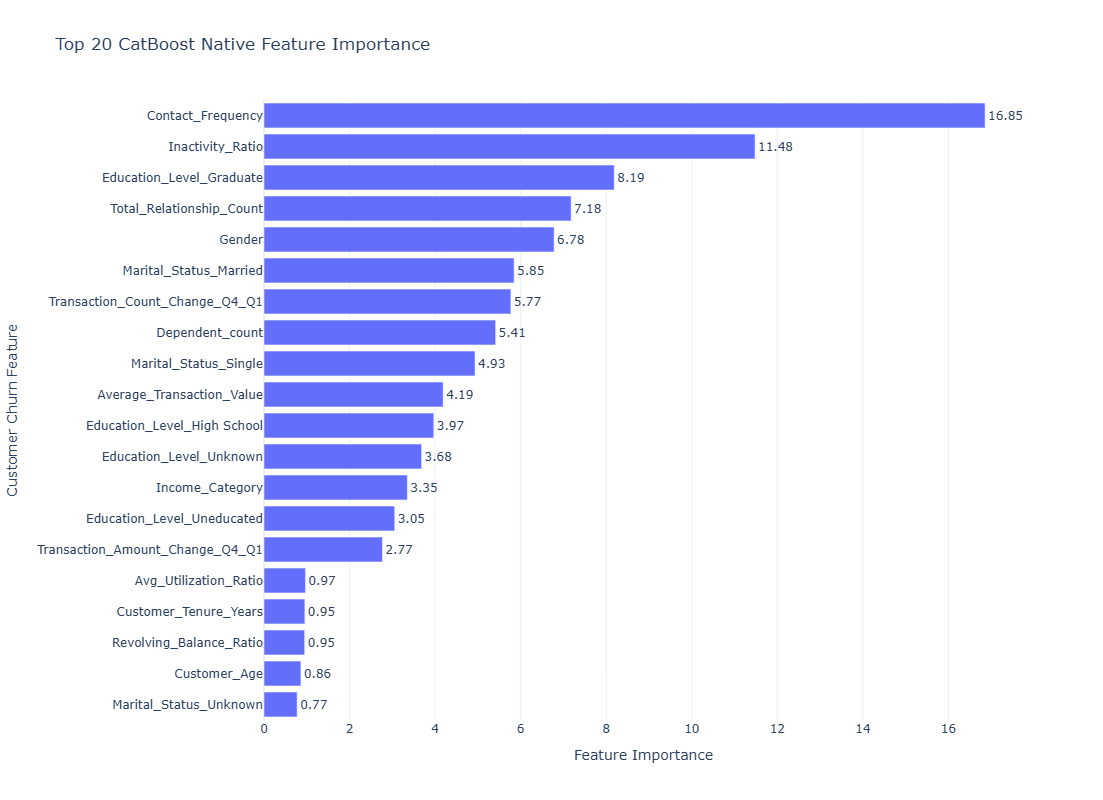


INITIALISING SHAP TREE EXPLAINER

Calculating SHAP values...

SHAP matrix shape: (2026, 25)

TOP 20 GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,Transaction_Count_Change_Q4_Q1,0.993657
1,Inactivity_Ratio,0.663701
2,Total_Relationship_Count,0.640069
3,Contact_Frequency,0.632185
4,Average_Transaction_Value,0.318845
5,Transaction_Amount_Change_Q4_Q1,0.277247
6,Gender,0.275052
7,Revolving_Balance_Ratio,0.274795
8,Avg_Utilization_Ratio,0.245542
9,Education_Level_Graduate,0.222518


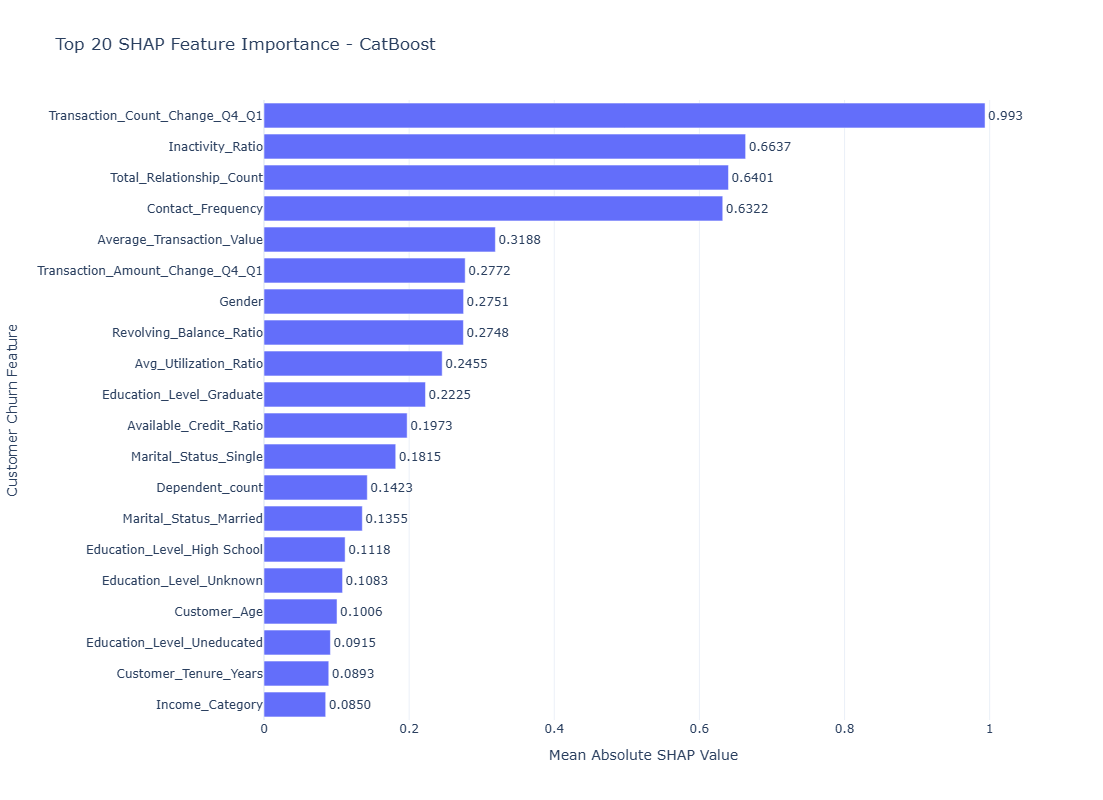

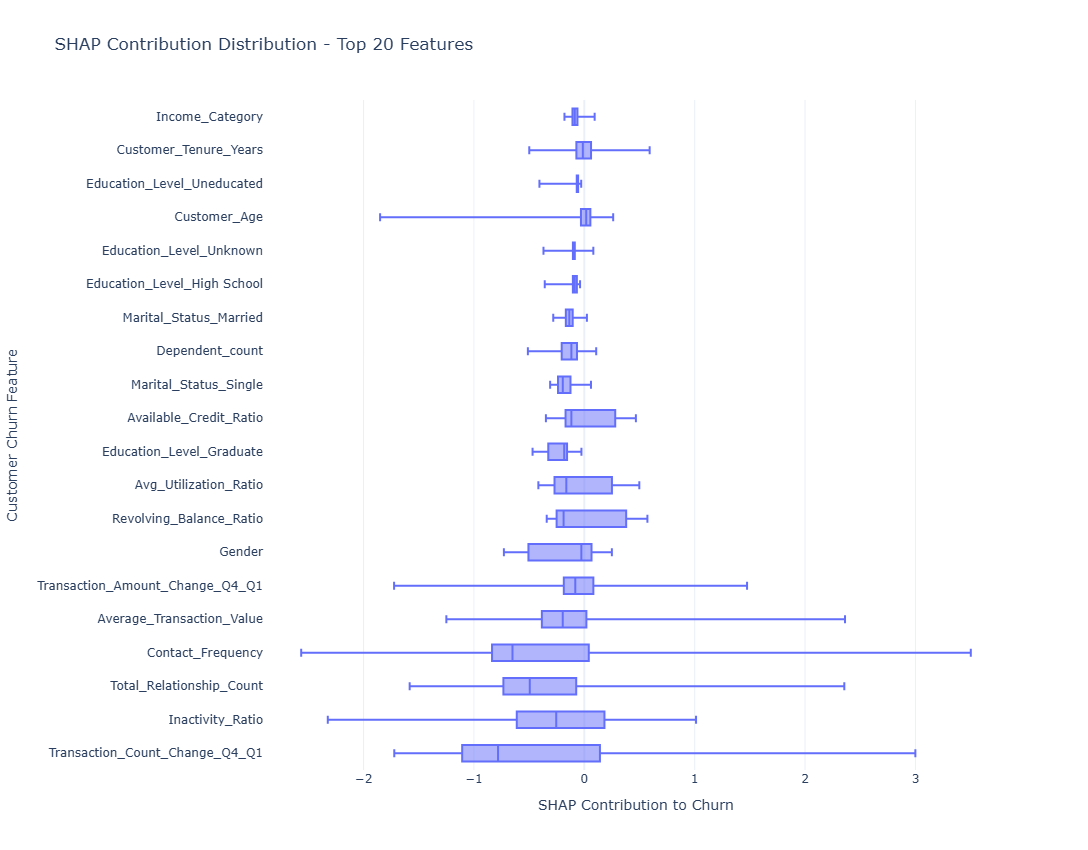

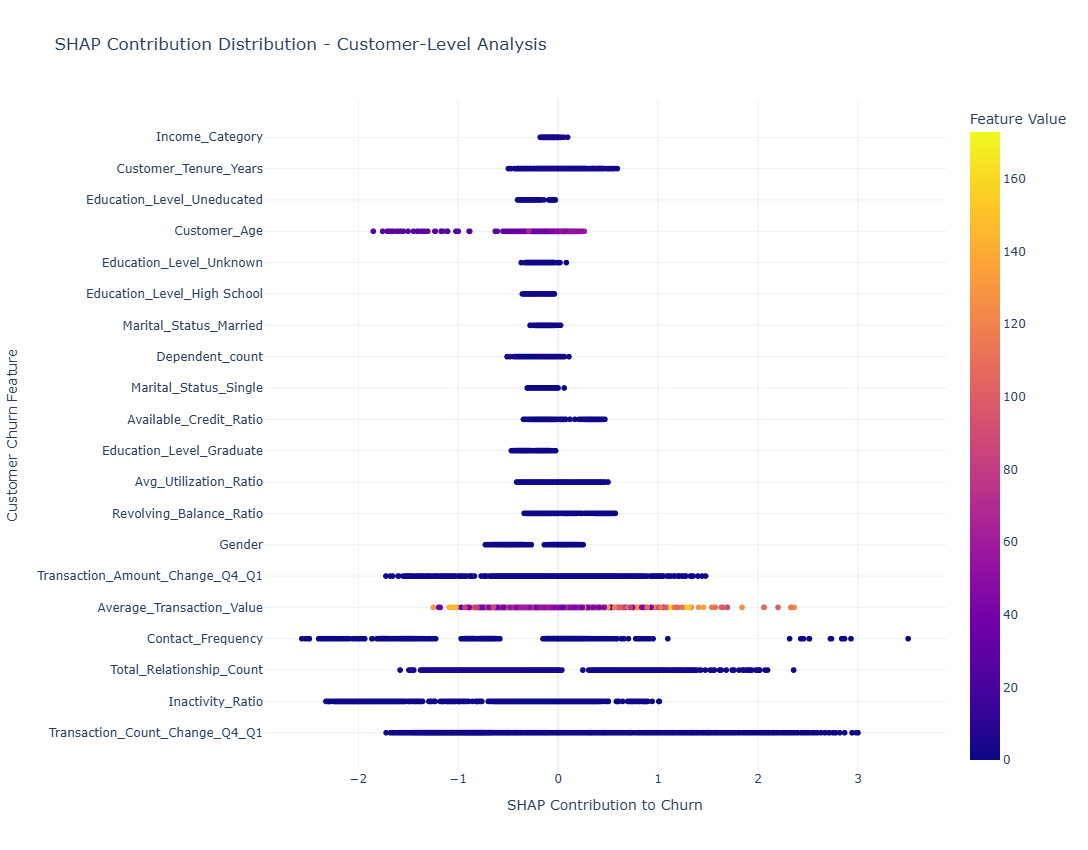


MOST IMPORTANT SHAP FEATURE

Most important feature: Transaction_Count_Change_Q4_Q1


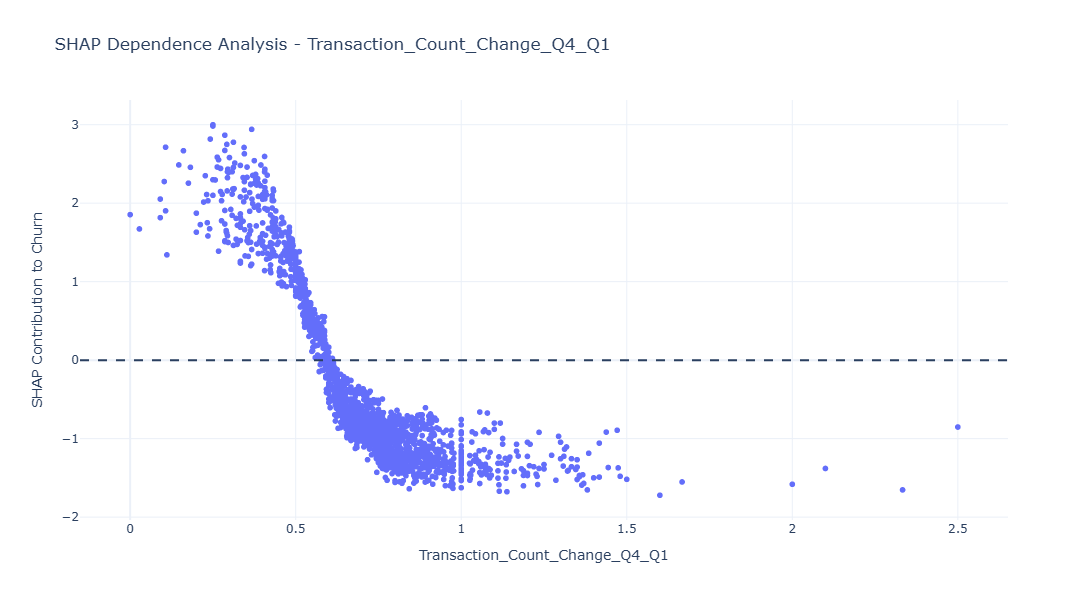


SHAP EXPLAINABILITY SUMMARY


,Feature,Mean_Absolute_SHAP,Mean_SHAP,Mean_Feature_Value
0,Transaction_Count_Change_Q4_Q1,0.993657,-0.367347,0.707638
1,Inactivity_Ratio,0.663701,-0.480758,0.193402
2,Total_Relationship_Count,0.640069,-0.262482,3.822804
3,Contact_Frequency,0.632185,-0.499279,0.204220
4,Average_Transaction_Value,0.318845,-0.152868,62.991623
5,Transaction_Amount_Change_Q4_Q1,0.277247,-0.068621,0.761243
6,Gender,0.275052,-0.203436,0.463968
7,Revolving_Balance_Ratio,0.274795,-0.037836,0.271802
8,Avg_Utilization_Ratio,0.245542,-0.064578,0.271796
9,Education_Level_Graduate,0.222518,-0.222518,0.318855



Saved: paystone_catboost_native_feature_importance.csv
Saved: paystone_catboost_global_shap_importance.csv
Saved: paystone_catboost_shap_customer_contributions.csv
Saved: paystone_catboost_shap_summary.csv
Saved: paystone_catboost_top20_feature_importance.html
Saved: paystone_catboost_top20_shap_importance.html
Saved: paystone_catboost_shap_distribution.html
Saved: paystone_catboost_shap_customer_scatter.html
Saved: paystone_catboost_shap_dependence.html

PAYSTONE CATBOOST EXPLAINABILITY PIPELINE COMPLETE

Final Model Analysed : Baseline CatBoost
Total Features      : 25
Top SHAP Feature     : Transaction_Count_Change_Q4_Q1

Visualisations generated:
1. Top 20 CatBoost native feature importance
2. Top 20 global SHAP feature importance
3. SHAP contribution distribution
4. SHAP customer-level contribution scatter
5. SHAP dependence analysis

Output files generated:
1. CatBoost native feature importance CSV
2. Global SHAP importance CSV
3. Customer-level SHAP contributions CSV
4. SHAP su

In [19]:
# =============================================================================
# PAYSTONE CUSTOMER CHURN - CATBOOST FEATURE IMPORTANCE & SHAP EXPLAINABILITY
# PLOTLY-ONLY VISUALISATION PIPELINE
# =============================================================================
#
# Objective:
# =============================================================================
#
# This pipeline performs post-model explainability for the final CatBoost
# customer churn model.
#
# IMPORTANT:
# =============================================================================
#
# SHAP is used ONLY to calculate feature contribution values.
#
# Matplotlib-based SHAP visualisations are NOT used.
#
# All visualisations are created using Plotly to avoid Matplotlib font and
# rendering errors such as:
#
#     LastResortHE-Regular.ttf
#
# The pipeline therefore provides:
#
#     1. CatBoost native feature importance
#     2. Top 20 CatBoost feature importance
#     3. SHAP global feature importance
#     4. Top 20 SHAP feature importance
#     5. SHAP contribution distribution
#     6. SHAP contribution scatter plot
#     7. SHAP dependence analysis
#     8. Interactive Plotly visualisations
#     9. CSV output files
#    10. HTML output files
#
# =============================================================================


# =============================================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# =============================================================================
#
# pandas:
#     Used for creating and manipulating feature-importance tables.
#
# numpy:
#     Used for numerical calculations.
#
# plotly.express:
#     Used for simple interactive charts.
#
# plotly.graph_objects:
#     Used for more customised interactive visualisations.
#
# shap:
#     Used to calculate SHAP values for model explainability.
#
# =============================================================================

# =============================================================================
# STEP 2: CONFIRM FINAL CATBOOST MODEL
# =============================================================================
#
# The previous CatBoost tuning pipeline should already have selected the final
# model.
#
# The expected objects are:
#
#     final_catboost
#     final_model_type
#     X_train
#     X_test
#     y_test
#
# The explainability analysis is performed on the selected final model.
#
# =============================================================================

print("\n" + "="*80)

print("PAYSTONE CUSTOMER CHURN - CATBOOST EXPLAINABILITY")

print("="*80)


print(f"\nFinal Model: {final_model_type}")

print(f"Training Features: {X_train.shape[1]}")

print(f"Test Observations: {X_test.shape[0]}")



# =============================================================================
# STEP 3: CALCULATE CATBOOST NATIVE FEATURE IMPORTANCE
# =============================================================================
#
# CatBoost provides a built-in feature importance method.
#
# The importance score indicates the relative contribution of each feature
# to the CatBoost model.
#
# Higher values indicate greater importance.
#
# This is independent of SHAP and provides a model-native interpretation.
#
# =============================================================================

catboost_importance = final_catboost.get_feature_importance()



# =============================================================================
# STEP 4: CREATE CATBOOST FEATURE IMPORTANCE DATAFRAME
# =============================================================================
#
# The feature names from X_train are matched with the CatBoost importance
# scores.
#
# The table is then sorted from most important to least important.
#
# =============================================================================

catboost_feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": catboost_importance

})


catboost_feature_importance = (

    catboost_feature_importance

    .sort_values(

        by="Importance",

        ascending=False

    )

    .reset_index(drop=True)

)



# =============================================================================
# STEP 5: EXTRACT TOP 20 CATBOOST FEATURES
# =============================================================================
#
# The top 20 features are extracted to provide a concise view of the most
# influential variables in the CatBoost model.
#
# =============================================================================

top_20_catboost_features = (

    catboost_feature_importance

    .head(20)

)


print("\n" + "="*80)

print("TOP 20 CATBOOST NATIVE FEATURE IMPORTANCE")

print("="*80)


display(

    top_20_catboost_features

)



# =============================================================================
# STEP 6: PLOT TOP 20 CATBOOST FEATURE IMPORTANCE USING PLOTLY
# =============================================================================
#
# Plotly is used instead of Matplotlib.
#
# A horizontal bar chart is used because feature names may be long.
#
# The most important feature is displayed at the top.
#
# =============================================================================

catboost_importance_fig = px.bar(

    top_20_catboost_features.sort_values(

        "Importance",

        ascending=True

    ),

    x="Importance",

    y="Feature",

    orientation="h",

    text="Importance",

    title="Top 20 CatBoost Native Feature Importance",

    labels={

        "Importance": "Feature Importance",

        "Feature": "Customer Churn Feature"

    }

)


catboost_importance_fig.update_traces(

    texttemplate="%{text:.2f}",

    textposition="outside"

)


catboost_importance_fig.update_layout(

    width=1000,

    height=800,

    template="plotly_white"

)


catboost_importance_fig.show()



# =============================================================================
# STEP 7: INITIALISE SHAP TREE EXPLAINER
# =============================================================================
#
# SHAP TreeExplainer is specifically designed for tree-based machine-learning
# models such as CatBoost.
#
# SHAP calculates the contribution of each feature to each prediction.
#
# =============================================================================

print("\n" + "="*80)

print("INITIALISING SHAP TREE EXPLAINER")

print("="*80)


explainer = shap.TreeExplainer(

    final_catboost

)



# =============================================================================
# STEP 8: CALCULATE SHAP VALUES
# =============================================================================
#
# SHAP values are calculated for X_test.
#
# X_test is used because these observations were not used to fit the final
# model.
#
# This provides an out-of-sample explanation of the model's behaviour.
#
# =============================================================================

print("\nCalculating SHAP values...")



shap_values = explainer.shap_values(

    X_test

)


# =============================================================================
# STEP 9: HANDLE SHAP BINARY CLASSIFICATION OUTPUT
# =============================================================================
#
# Depending on the SHAP version, binary classification output can be returned
# either as:
#
#     - a NumPy array
#     - a list containing class-specific arrays
#
# We select the churn class where required.
#
# =============================================================================

if isinstance(shap_values, list):

    shap_churn_values = shap_values[1]

else:

    shap_churn_values = shap_values


print(

    f"\nSHAP matrix shape: {shap_churn_values.shape}"

)



# =============================================================================
# STEP 10: CREATE GLOBAL SHAP FEATURE IMPORTANCE
# =============================================================================
#
# Global SHAP importance is calculated using:
#
#     Mean Absolute SHAP Value
#
# Formula:
#
#     Mean(|SHAP Value|)
#
# Taking the absolute value prevents positive and negative contributions from
# cancelling each other out.
#
# A larger value means that the feature has a stronger overall influence on
# the model's predictions.
#
# =============================================================================

global_shap_importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean_Absolute_SHAP":

        np.abs(shap_churn_values).mean(axis=0)

})


global_shap_importance = (

    global_shap_importance

    .sort_values(

        by="Mean_Absolute_SHAP",

        ascending=False

    )

    .reset_index(drop=True)

)



# =============================================================================
# STEP 11: DISPLAY TOP 20 SHAP FEATURES
# =============================================================================
#
# The top 20 features are displayed according to their global SHAP importance.
#
# =============================================================================

top_20_shap_features = (

    global_shap_importance

    .head(20)

)


print("\n" + "="*80)

print("TOP 20 GLOBAL SHAP FEATURE IMPORTANCE")

print("="*80)


display(

    top_20_shap_features

)



# =============================================================================
# STEP 12: PLOT TOP 20 SHAP FEATURE IMPORTANCE USING PLOTLY
# =============================================================================
#
# This replaces the standard SHAP bar plot.
#
# No Matplotlib functionality is used.
#
# =============================================================================

shap_importance_fig = px.bar(

    top_20_shap_features.sort_values(

        "Mean_Absolute_SHAP",

        ascending=True

    ),

    x="Mean_Absolute_SHAP",

    y="Feature",

    orientation="h",

    text="Mean_Absolute_SHAP",

    title="Top 20 SHAP Feature Importance - CatBoost",

    labels={

        "Mean_Absolute_SHAP":

            "Mean Absolute SHAP Value",

        "Feature":

            "Customer Churn Feature"

    }

)


shap_importance_fig.update_traces(

    texttemplate="%{text:.4f}",

    textposition="outside"

)


shap_importance_fig.update_layout(

    width=1000,

    height=800,

    template="plotly_white"

)


shap_importance_fig.show()



# =============================================================================
# STEP 13: PREPARE SHAP CONTRIBUTION DATA
# =============================================================================
#
# This section converts the SHAP matrix into a long-format DataFrame.
#
# Long-format data is particularly useful for Plotly because it allows each
# feature to be displayed against its individual SHAP contributions.
#
# =============================================================================

top_features = (

    top_20_shap_features["Feature"]

    .tolist()

)


shap_long_data = []


for feature in top_features:

    feature_index = X_test.columns.get_loc(feature)

    feature_values = X_test[feature].values

    feature_shap_values = shap_churn_values[:, feature_index]


    for feature_value, shap_value in zip(

        feature_values,

        feature_shap_values

    ):

        shap_long_data.append({

            "Feature": feature,

            "Feature_Value": feature_value,

            "SHAP_Value": shap_value

        })


shap_long_df = pd.DataFrame(

    shap_long_data

)



# =============================================================================
# STEP 14: PLOT SHAP CONTRIBUTION DISTRIBUTION USING PLOTLY
# =============================================================================
#
# The box plot displays the distribution of SHAP contributions for each of the
# top 20 features.
#
# Interpretation:
#
#     Positive SHAP value:
#         Pushes the prediction towards churn.
#
#     Negative SHAP value:
#         Pushes the prediction towards existing customer.
#
#     Values close to zero:
#         Limited contribution to that customer's prediction.
#
# =============================================================================

shap_distribution_fig = px.box(

    shap_long_df,

    x="SHAP_Value",

    y="Feature",

    orientation="h",

    points=False,

    title="SHAP Contribution Distribution - Top 20 Features",

    labels={

        "SHAP_Value":

            "SHAP Contribution to Churn",

        "Feature":

            "Customer Churn Feature"

    }

)


shap_distribution_fig.update_layout(

    width=1100,

    height=850,

    template="plotly_white"

)


shap_distribution_fig.show()



# =============================================================================
# STEP 15: CREATE SHAP CONTRIBUTION SCATTER PLOT
# =============================================================================
#
# This Plotly visualisation replaces the Matplotlib SHAP beeswarm plot.
#
# Each point represents one customer observation.
#
# X-axis:
#     SHAP contribution.
#
# Y-axis:
#     Feature.
#
# Colour:
#     Feature value.
#
# Positive SHAP values indicate a contribution towards higher churn
# probability, while negative values indicate a contribution towards lower
# churn probability.
#
# =============================================================================

shap_scatter_fig = px.scatter(

    shap_long_df,

    x="SHAP_Value",

    y="Feature",

    color="Feature_Value",

    hover_data=[

        "Feature_Value",

        "SHAP_Value"

    ],

    title="SHAP Contribution Distribution - Customer-Level Analysis",

    labels={

        "SHAP_Value":

            "SHAP Contribution to Churn",

        "Feature":

            "Customer Churn Feature",

        "Feature_Value":

            "Feature Value"

    }

)


shap_scatter_fig.update_layout(

    width=1100,

    height=850,

    template="plotly_white"

)


shap_scatter_fig.show()



# =============================================================================
# STEP 16: IDENTIFY MOST IMPORTANT SHAP FEATURE
# =============================================================================
#
# The feature with the largest mean absolute SHAP value is identified as the
# most influential feature in the final CatBoost model.
#
# =============================================================================

most_important_feature = (

    global_shap_importance

    .iloc[0]["Feature"]

)


print("\n" + "="*80)

print("MOST IMPORTANT SHAP FEATURE")

print("="*80)


print(

    f"\nMost important feature: "

    f"{most_important_feature}"

)



# =============================================================================
# STEP 17: CREATE SHAP DEPENDENCE DATA
# =============================================================================
#
# A SHAP dependence plot normally examines the relationship between a feature
# value and its SHAP contribution.
#
# Instead of using SHAP's Matplotlib dependence_plot(), we manually construct
# the same concept using Plotly.
#
# This completely avoids Matplotlib.
#
# =============================================================================

most_feature_index = X_test.columns.get_loc(

    most_important_feature

)


dependence_df = pd.DataFrame({

    "Feature_Value":

        X_test[most_important_feature].values,

    "SHAP_Value":

        shap_churn_values[:, most_feature_index]

})


# =============================================================================
# STEP 18: PLOT SHAP DEPENDENCE USING PLOTLY
# =============================================================================
#
# This chart shows how the most important feature affects the model's churn
# prediction.
#
# Interpretation:
#
#     X-axis:
#         Actual feature value.
#
#     Y-axis:
#         SHAP contribution.
#
#     SHAP > 0:
#         Feature pushes prediction towards churn.
#
#     SHAP < 0:
#         Feature pushes prediction towards existing customer.
#
# =============================================================================

shap_dependence_fig = px.scatter(

    dependence_df,

    x="Feature_Value",

    y="SHAP_Value",

    title=(

        "SHAP Dependence Analysis - "

        f"{most_important_feature}"

    ),

    labels={

        "Feature_Value":

            most_important_feature,

        "SHAP_Value":

            "SHAP Contribution to Churn"

    }

)


# Add horizontal zero reference line

shap_dependence_fig.add_hline(

    y=0,

    line_dash="dash"

)


shap_dependence_fig.update_layout(

    width=900,

    height=600,

    template="plotly_white"

)


shap_dependence_fig.show()



# =============================================================================
# STEP 19: CREATE SHAP IMPORTANCE + FEATURE VALUE SUMMARY
# =============================================================================
#
# This table combines:
#
#     - Mean absolute SHAP importance
#     - Mean SHAP contribution
#     - Mean feature value
#
# The mean SHAP value gives an indication of the overall direction of the
# feature's influence.
#
# =============================================================================

shap_summary_table = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean_Absolute_SHAP":

        np.abs(shap_churn_values).mean(axis=0),

    "Mean_SHAP":

        shap_churn_values.mean(axis=0),

    "Mean_Feature_Value":

        X_test.mean(numeric_only=True).reindex(

            X_test.columns

        ).values

})


shap_summary_table = (

    shap_summary_table

    .sort_values(

        "Mean_Absolute_SHAP",

        ascending=False

    )

    .reset_index(drop=True)

)


print("\n" + "="*80)

print("SHAP EXPLAINABILITY SUMMARY")

print("="*80)


display(

    shap_summary_table.head(20)

)



# =============================================================================
# STEP 20: SAVE CATBOOST FEATURE IMPORTANCE
# =============================================================================
#
# The complete CatBoost native feature importance table is saved as CSV.
#
# =============================================================================

catboost_feature_importance.to_csv(

    "paystone_catboost_native_feature_importance.csv",

    index=False

)


print(

    "\nSaved: "

    "paystone_catboost_native_feature_importance.csv"

)



# =============================================================================
# STEP 21: SAVE GLOBAL SHAP FEATURE IMPORTANCE
# =============================================================================
#
# This file contains the global SHAP importance for every model feature.
#
# =============================================================================

global_shap_importance.to_csv(

    "paystone_catboost_global_shap_importance.csv",

    index=False

)


print(

    "Saved: "

    "paystone_catboost_global_shap_importance.csv"

)



# =============================================================================
# STEP 22: SAVE SHAP CONTRIBUTION DATA
# =============================================================================
#
# Customer-level SHAP contributions for the top 20 features are saved.
#
# This can later be used for dashboards, customer-level explanations or
# further statistical analysis.
#
# =============================================================================

shap_long_df.to_csv(

    "paystone_catboost_shap_customer_contributions.csv",

    index=False

)


print(

    "Saved: "

    "paystone_catboost_shap_customer_contributions.csv"

)



# =============================================================================
# STEP 23: SAVE SHAP SUMMARY TABLE
# =============================================================================

shap_summary_table.to_csv(

    "paystone_catboost_shap_summary.csv",

    index=False

)


print(

    "Saved: "

    "paystone_catboost_shap_summary.csv"

)



# =============================================================================
# STEP 24: SAVE TOP 20 CATBOOST FEATURE IMPORTANCE PLOT
# =============================================================================
#
# Plotly HTML files retain their interactive functionality.
#
# =============================================================================

catboost_importance_fig.write_html(

    "paystone_catboost_top20_feature_importance.html"

)


print(

    "Saved: "

    "paystone_catboost_top20_feature_importance.html"

)



# =============================================================================
# STEP 25: SAVE TOP 20 SHAP IMPORTANCE PLOT
# =============================================================================

shap_importance_fig.write_html(

    "paystone_catboost_top20_shap_importance.html"

)


print(

    "Saved: "

    "paystone_catboost_top20_shap_importance.html"

)



# =============================================================================
# STEP 26: SAVE SHAP CONTRIBUTION DISTRIBUTION
# =============================================================================

shap_distribution_fig.write_html(

    "paystone_catboost_shap_distribution.html"

)


print(

    "Saved: "

    "paystone_catboost_shap_distribution.html"

)



# =============================================================================
# STEP 27: SAVE SHAP CUSTOMER-LEVEL SCATTER PLOT
# =============================================================================

shap_scatter_fig.write_html(

    "paystone_catboost_shap_customer_scatter.html"

)


print(

    "Saved: "

    "paystone_catboost_shap_customer_scatter.html"

)



# =============================================================================
# STEP 28: SAVE SHAP DEPENDENCE PLOT
# =============================================================================

shap_dependence_fig.write_html(

    "paystone_catboost_shap_dependence.html"

)


print(

    "Saved: "

    "paystone_catboost_shap_dependence.html"

)



# =============================================================================
# STEP 29: FINAL EXPLAINABILITY SUMMARY
# =============================================================================
#
# This confirms that the complete Plotly-based explainability pipeline has
# finished successfully.
#
# No Matplotlib visualisation is called anywhere in this pipeline.
#
# =============================================================================

print("\n" + "="*80)

print("PAYSTONE CATBOOST EXPLAINABILITY PIPELINE COMPLETE")

print("="*80)


print(f"\nFinal Model Analysed : {final_model_type}")

print(

    f"Total Features      : "

    f"{len(catboost_feature_importance)}"

)

print(

    f"Top SHAP Feature     : "

    f"{most_important_feature}"

)


print("\nVisualisations generated:")

print("1. Top 20 CatBoost native feature importance")

print("2. Top 20 global SHAP feature importance")

print("3. SHAP contribution distribution")

print("4. SHAP customer-level contribution scatter")

print("5. SHAP dependence analysis")


print("\nOutput files generated:")

print("1. CatBoost native feature importance CSV")

print("2. Global SHAP importance CSV")

print("3. Customer-level SHAP contributions CSV")

print("4. SHAP summary CSV")

print("5. CatBoost feature importance HTML")

print("6. SHAP importance HTML")

print("7. SHAP distribution HTML")

print("8. SHAP customer scatter HTML")

print("9. SHAP dependence HTML")


print("\n" + "="*80)

print("IMPORTANT: Matplotlib was not used for any visualisation.")

print("="*80)

# Business Insight KPI

In [23]:
# =============================================================================
# === STEP 19: FINAL CATBOOST KPI EXTRACTION - NO KPI AVERAGING ===
# =============================================================================
#
# PURPOSE
# =============================================================================
#
# This pipeline extracts business KPIs directly from the final CatBoost
# customer-level predictions.
#
# IMPORTANT:
# =============================================================================
#
# The pipeline does NOT calculate an average of the KPI values.
#
# Instead, it:
#
# 1. Generates customer-level churn predictions.
# 2. Generates individual customer churn probabilities.
# 3. Identifies high-risk customers.
# 4. Identifies high-value customers.
# 5. Identifies high-value customers at risk.
# 6. Calculates business rates using counts.
# 7. Saves the complete customer-level prediction dataset.
# 8. Saves a KPI dataset containing the extracted business metrics.
#
#
# KPI OUTPUTS
# =============================================================================
#
# 1. Total Customers
# 2. Churned Customers
# 3. Churn Rate (%)
# 4. High-Risk Customers
# 5. High-Risk Customers (%)
# 6. Retained Customers
# 7. Retention Rate (%)
# 8. High-Value Customers
# 9. High-Value Customers At Risk
# 10. Total Predicted Churn Probability
#
#
# NOTE:
# =============================================================================
#
# "Average Churn Probability (%)" has deliberately been removed because
# the requirement is to avoid calculating averages.
#
# Individual customer churn probabilities remain available in:
#
#     customer_churn_predictions.csv
#
# Therefore, the dashboard can calculate any required probability statistic
# later without modifying the underlying prediction dataset.
#
# =============================================================================


def extract_churn_kpis(
    
    final_catboost,
    X_test,
    y_test=None,
    high_risk_threshold=0.50,
    high_value_percentile=0.75,
    value_column="TotalCharges",
    kpi_output_file="KPI.csv",
    prediction_output_file="customer_churn_predictions.csv"

):

    """
    Extract customer-level predictions and business KPIs from the final
    CatBoost model without averaging KPI values.

    Parameters
    ----------
    final_catboost : CatBoostClassifier
        Final trained CatBoost model.

    X_test : pandas.DataFrame
        Unseen test dataset.

    y_test : array-like, optional
        Actual churn outcomes.

    high_risk_threshold : float
        Probability threshold for high-risk classification.

    high_value_percentile : float
        Percentile threshold for high-value customers.

    value_column : str
        Customer value variable.

    kpi_output_file : str
        Output filename for KPI data.

    prediction_output_file : str
        Output filename for customer-level predictions.

    Returns
    -------
    kpi_data : pandas.DataFrame
        Extracted business KPI dataset.

    customer_predictions : pandas.DataFrame
        Customer-level prediction dataset.

    """


    # =========================================================================
    # === STEP 1: VALIDATE INPUT DATA ===
    # =========================================================================

    if X_test is None or len(X_test) == 0:

        raise ValueError(
            "X_test is empty. Customer KPI extraction cannot continue."
        )


    if final_catboost is None:

        raise ValueError(
            "final_catboost was not supplied."
        )


    # =========================================================================
    # === STEP 2: GENERATE FINAL CATBOOST PREDICTIONS ===
    # =========================================================================
    #
    # predict() returns the final classification:
    #
    #     0 = Retained / Non-Churn
    #     1 = Churn
    #
    # =========================================================================

    predicted_churn = (

        final_catboost.predict(X_test)

    ).ravel().astype(int)


    # =========================================================================
    # === STEP 3: GENERATE CUSTOMER-LEVEL CHURN PROBABILITIES ===
    # =========================================================================
    #
    # predict_proba() produces probabilities for both classes.
    #
    # Column 0 = Retention probability
    # Column 1 = Churn probability
    #
    # We extract only the probability of churn.
    #
    # =========================================================================

    churn_probability = (

        final_catboost.predict_proba(X_test)[:, 1]

    )


    # =========================================================================
    # === STEP 4: VALIDATE PREDICTION LENGTHS ===
    # =========================================================================

    if len(predicted_churn) != len(X_test):

        raise ValueError(
            "Predicted churn length does not match X_test."
        )


    if len(churn_probability) != len(X_test):

        raise ValueError(
            "Churn probability length does not match X_test."
        )


    # =========================================================================
    # === STEP 5: CREATE CUSTOMER-LEVEL PREDICTION DATASET ===
    # =========================================================================
    #
    # A customer-level dataset is created first.
    #
    # This is important because all business KPIs should originate from
    # customer-level model outputs.
    #
    # =========================================================================

    customer_predictions = X_test.copy()


    # Preserve original X_test index where possible.

    customer_predictions = customer_predictions.reset_index(
        drop=True
    )


    # =========================================================================
    # === STEP 6: ADD ACTUAL CHURN OUTCOME ===
    # =========================================================================

    if y_test is not None:

        actual_churn = np.asarray(
            y_test
        ).reshape(-1)

        if len(actual_churn) != len(customer_predictions):

            raise ValueError(
                "y_test length does not match X_test."
            )

        customer_predictions["Actual_Churn"] = (
            actual_churn.astype(int)
        )


    # =========================================================================
    # === STEP 7: ADD MODEL PREDICTIONS ===
    # =========================================================================

    customer_predictions["Predicted_Churn"] = predicted_churn


    # =========================================================================
    # === STEP 8: ADD CUSTOMER CHURN PROBABILITY ===
    # =========================================================================
    #
    # The individual probability for every customer is retained.
    #
    # Example:
    #
    # Customer A -> 0.82
    # Customer B -> 0.21
    # Customer C -> 0.67
    #
    # No averaging is performed here.
    #
    # =========================================================================

    customer_predictions["Churn_Probability"] = (
        churn_probability
    )


    customer_predictions["Churn_Probability_%"] = (
        churn_probability * 100
    ).round(2)


    # =========================================================================
    # === STEP 9: CREATE PREDICTED CUSTOMER STATUS ===
    # =========================================================================

    customer_predictions["Predicted_Status"] = np.where(

        predicted_churn == 1,

        "Churn",

        "Retained"

    )


    # =========================================================================
    # === STEP 10: CREATE HIGH-RISK FLAG ===
    # =========================================================================
    #
    # A customer is high risk when:
    #
    #     Churn Probability >= 50%
    #
    # =========================================================================

    high_risk_flag = (

        churn_probability >= high_risk_threshold

    ).astype(int)


    customer_predictions["High_Risk"] = high_risk_flag


    # =========================================================================
    # === STEP 11: CREATE RISK CATEGORY ===
    # =========================================================================

    customer_predictions["Risk_Category"] = np.where(

        high_risk_flag == 1,

        "High Risk",

        "Lower Risk"

    )


    # =========================================================================
    # === STEP 12: IDENTIFY HIGH-VALUE CUSTOMERS ===
    # =========================================================================
    #
    # High-value customers are defined as customers at or above the selected
    # percentile of the customer-value variable.
    #
    # Default:
    #
    # 75th percentile = top 25% of customers.
    #
    # =========================================================================

    high_value_flag = np.zeros(
        len(customer_predictions),
        dtype=int
    )


    high_value_threshold = np.nan


    if value_column in customer_predictions.columns:

        customer_value = pd.to_numeric(

            customer_predictions[value_column],

            errors="coerce"

        )


        if customer_value.notna().sum() > 0:

            high_value_threshold = (

                customer_value.quantile(
                    high_value_percentile
                )

            )


            high_value_flag = (

                customer_value >= high_value_threshold

            ).astype(int).to_numpy()


    else:

        print(
            f"\nWARNING: '{value_column}' was not found."
        )


    customer_predictions["High_Value"] = high_value_flag


    # =========================================================================
    # === STEP 13: IDENTIFY HIGH-VALUE CUSTOMERS AT RISK ===
    # =========================================================================
    #
    # A customer must satisfy BOTH conditions:
    #
    #     High Value = 1
    #
    # AND
    #
    #     High Risk = 1
    #
    # =========================================================================

    high_value_at_risk_flag = (

        (high_value_flag == 1)

        &

        (high_risk_flag == 1)

    ).astype(int)


    customer_predictions["High_Value_At_Risk"] = (
        high_value_at_risk_flag
    )


    # =========================================================================
    # === STEP 14: EXTRACT RAW CUSTOMER COUNTS ===
    # =========================================================================
    #
    # These are direct counts from the model predictions.
    #
    # No averaging of KPI values is performed.
    #
    # =========================================================================

    total_customers = len(
        customer_predictions
    )


    predicted_churn_customers = int(
        (predicted_churn == 1).sum()
    )


    predicted_retained_customers = int(
        (predicted_churn == 0).sum()
    )


    high_risk_customers = int(
        high_risk_flag.sum()
    )


    high_value_customers = int(
        high_value_flag.sum()
    )


    high_value_customers_at_risk = int(
        high_value_at_risk_flag.sum()
    )


    # =========================================================================
    # === STEP 15: CALCULATE CHURN RATE ===
    # =========================================================================
    #
    # Churn Rate is a business ratio, not an average.
    #
    # Formula:
    #
    #     Churned Customers
    #     ----------------- × 100
    #     Total Customers
    #
    # =========================================================================

    churn_rate = (

        predicted_churn_customers
        /
        total_customers

    ) * 100


    # =========================================================================
    # === STEP 16: CALCULATE HIGH-RISK CUSTOMER RATE ===
    # =========================================================================

    high_risk_percentage = (

        high_risk_customers
        /
        total_customers

    ) * 100


    # =========================================================================
    # === STEP 17: CALCULATE RETENTION RATE ===
    # =========================================================================
    #
    # Retention Rate is based directly on retained customer count.
    #
    # =========================================================================

    retention_rate = (

        predicted_retained_customers
        /
        total_customers

    ) * 100


    # =========================================================================
    # === STEP 18: EXTRACT TOTAL PREDICTED CHURN PROBABILITY ===
    # =========================================================================
    #
    # IMPORTANT:
    #
    # We do NOT calculate the average probability.
    #
    # Instead, we retain the total probability mass across the test
    # population.
    #
    # The individual customer probabilities are already available in
    # customer_predictions.
    #
    # =========================================================================

    total_predicted_churn_probability = (
        churn_probability.sum()
    )


    # =========================================================================
    # === STEP 19: CREATE KPI DATAFRAME ===
    # =========================================================================
    #
    # The KPI dataframe contains business-level values.
    #
    # No KPI averaging is performed.
    #
    # =========================================================================

    kpi_data = pd.DataFrame({

        "KPI": [

            "Total Customers",

            "Predicted Churn Customers",

            "Churn Rate (%)",

            "High-Risk Customers",

            "High-Risk Customers (%)",

            "Predicted Retained Customers",

            "Retention Rate (%)",

            "High-Value Customers",

            "High-Value Customers At Risk",

            "Total Predicted Churn Probability"

        ],

        "Value": [

            total_customers,

            predicted_churn_customers,

            round(churn_rate, 2),

            high_risk_customers,

            round(high_risk_percentage, 2),

            predicted_retained_customers,

            round(retention_rate, 2),

            high_value_customers,

            high_value_customers_at_risk,

            round(
                total_predicted_churn_probability,
                4
            )

        ]

    })


    # =========================================================================
    # === STEP 20: SAVE CUSTOMER-LEVEL DATASET ===
    # =========================================================================
    #
    # This is the most important dataset for downstream analysis.
    #
    # It can be used for:
    #
    # - Power BI
    # - Streamlit
    # - Customer retention campaigns
    # - Risk segmentation
    # - Customer-level investigation
    # - Explainable AI
    #
    # =========================================================================

    customer_predictions.to_csv(

        prediction_output_file,

        index=False

    )


    # =========================================================================
    # === STEP 21: SAVE KPI DATASET ===
    # =========================================================================

    kpi_data.to_csv(

        kpi_output_file,

        index=False

    )


    # =========================================================================
    # === STEP 22: DISPLAY KPI RESULTS ===
    # =========================================================================

    print("\n" + "=" * 90)

    print(
        "PAYSTONE CUSTOMER CHURN - FINAL BUSINESS KPIs"
    )

    print("=" * 90)


    display(
        kpi_data
    )


    # =========================================================================
    # === STEP 23: DISPLAY OUTPUT FILES ===
    # =========================================================================

    print("\n" + "=" * 90)

    print("GENERATED OUTPUT FILES")

    print("=" * 90)


    print(
        f"\n1. {kpi_output_file}"
    )

    print(
        "   -> Business KPI dataset"
    )


    print(
        f"\n2. {prediction_output_file}"
    )

    print(
        "   -> Customer-level CatBoost predictions"
    )


    print("\n" + "=" * 90)


    # =========================================================================
    # === STEP 24: RETURN DATASETS ===
    # =========================================================================

    return (

        kpi_data,

        customer_predictions

    )


# =============================================================================
# === STEP 25: EXECUTE FINAL KPI EXTRACTION ===
# =============================================================================

kpi_data, customer_predictions = extract_churn_kpis(

    final_catboost=final_catboost,

    X_test=X_test,

    y_test=y_test,

    high_risk_threshold=0.50,

    high_value_percentile=0.75,

    value_column="TotalCharges",

    kpi_output_file="KPI.csv",

    prediction_output_file="customer_churn_predictions.csv"

)


# =============================================================================
# === STEP 26: FINAL CONFIRMATION ===
# =============================================================================

print("\n" + "=" * 90)

print(
    "FINAL CATBOOST KPI EXTRACTION COMPLETED"
)

print("=" * 90)

print(
    "\nCustomer-level dataset:"
)

print(
    "customer_churn_predictions.csv"
)

print(
    "\nBusiness KPI dataset:"
)

print(
    "KPI.csv"
)

print("\n" + "=" * 90)



PAYSTONE CUSTOMER CHURN - FINAL BUSINESS KPIs


,KPI,Value
0,Total Customers,2026.0000
1,Predicted Churn Customers,252.0000
2,Churn Rate (%),12.4400
3,High-Risk Customers,252.0000
4,High-Risk Customers (%),12.4400
5,Predicted Retained Customers,1774.0000
6,Retention Rate (%),87.5600
7,High-Value Customers,0.0000
8,High-Value Customers At Risk,0.0000
9,Total Predicted Churn Probability,350.3168



GENERATED OUTPUT FILES

1. KPI.csv
   -> Business KPI dataset

2. customer_churn_predictions.csv
   -> Customer-level CatBoost predictions


FINAL CATBOOST KPI EXTRACTION COMPLETED

Customer-level dataset:
customer_churn_predictions.csv

Business KPI dataset:
KPI.csv



# Model Performance Metrics 

In [21]:
# =============================================================================
# STEP 15: AUTOMATED FINAL CATBOOST PERFORMANCE METRICS EXTRACTION
# =============================================================================
#
# PURPOSE
# =============================================================================
#
# This section automatically extracts the key performance metrics from the
# FINAL CatBoost model selected during the model-selection stage.
#
# The five performance metrics extracted are:
#
#     1. ROC-AUC Score
#     2. Accuracy
#     3. F1-Score
#     4. Precision
#     5. Recall
#
#
# IMPORTANT
# =============================================================================
#
# The metrics are calculated using X_test and y_test.
#
# X_test represents the unseen test customers that were not used to train
# the CatBoost model.
#
# Therefore, these metrics provide an independent assessment of the final
# model's predictive performance.
#
#
# OUTPUT
# =============================================================================
#
# The pipeline automatically creates:
#
#     catboost_performance_metrics.csv
#
# The CSV contains:
#
#     Metric
#     Score
#     Score (%)
#
# =============================================================================


# =============================================================================
# STEP 15.0: IMPORT REQUIRED PERFORMANCE METRICS
# =============================================================================
#
# These imports ensure that the required evaluation functions are available.
#
# If these functions have already been imported earlier in the notebook,
# Python will simply reuse them.
#
# =============================================================================

from sklearn.metrics import (

    roc_auc_score,

    accuracy_score,

    f1_score,

    precision_score,

    recall_score

)


# =============================================================================
# STEP 15.1: VALIDATE REQUIRED INPUTS
# =============================================================================
#
# Before calculating the metrics, confirm that the final CatBoost model,
# X_test and y_test are available.
#
# This prevents the pipeline from producing misleading results if a required
# object has not been created in an earlier step.
#
# =============================================================================

required_objects = [

    "final_catboost",

    "X_test",

    "y_test"

]


for object_name in required_objects:

    if object_name not in globals():

        raise NameError(

            f"Required object '{object_name}' was not found. "

            f"Please run the previous CatBoost modelling steps first."

        )


# =============================================================================
# STEP 15.2: DISPLAY MODEL EVALUATION START MESSAGE
# =============================================================================

print("\n" + "=" * 80)

print("AUTOMATED FINAL CATBOOST PERFORMANCE EVALUATION")

print("=" * 80)

print("\nModel being evaluated:")

print(

    type(final_catboost).__name__

)

print("\nEvaluation dataset:")

print(

    f"Unseen test dataset: {len(X_test):,} customers"

)


# =============================================================================
# STEP 15.3: GENERATE FINAL BINARY PREDICTIONS
# =============================================================================
#
# The final CatBoost model generates a binary churn classification for every
# customer in X_test.
#
# The expected interpretation is:
#
#     0 = Customer predicted not to churn
#     1 = Customer predicted to churn
#
# predict() is used for metrics that require a binary classification:
#
#     Accuracy
#     F1-Score
#     Precision
#     Recall
#
# =============================================================================

final_pred = (

    final_catboost.predict(

        X_test

    )

).ravel()


# =============================================================================
# STEP 15.4: GENERATE FINAL CHURN PROBABILITIES
# =============================================================================
#
# predict_proba() returns the probability associated with each class.
#
# For a binary churn model:
#
#     Column 0 = Probability of non-churn
#     Column 1 = Probability of churn
#
# Therefore [:, 1] extracts the probability of churn.
#
# The probability is required for ROC-AUC because ROC-AUC evaluates how well
# the model ranks customers according to their likelihood of churn.
#
# =============================================================================

final_prob = (

    final_catboost.predict_proba(

        X_test

    )[:, 1]

)


# =============================================================================
# STEP 15.5: VALIDATE PREDICTION DIMENSIONS
# =============================================================================
#
# The number of predictions and probabilities must be equal to the number of
# observations in X_test.
#
# This check protects the pipeline against accidental data misalignment.
#
# =============================================================================

if len(final_pred) != len(X_test):

    raise ValueError(

        "The number of binary predictions does not match X_test."

    )


if len(final_prob) != len(X_test):

    raise ValueError(

        "The number of churn probabilities does not match X_test."

    )


if len(y_test) != len(X_test):

    raise ValueError(

        "The number of y_test observations does not match X_test."

    )


# =============================================================================
# STEP 15.6: CALCULATE ROC-AUC SCORE
# =============================================================================
#
# ROC-AUC measures the model's ability to discriminate between:
#
#     0 = Non-churn customers
#     1 = Churn customers
#
# IMPORTANT:
#
# ROC-AUC uses the predicted churn probabilities rather than the binary
# predictions.
#
# Therefore final_prob is used rather than final_pred.
#
#
# Interpretation:
#
#     0.50 = Random discrimination
#     0.60-0.70 = Weak discrimination
#     0.70-0.80 = Acceptable discrimination
#     0.80-0.90 = Good discrimination
#     >0.90 = Excellent discrimination
#
# These ranges are general interpretation guidelines rather than strict
# regulatory thresholds.
#
# =============================================================================

roc_auc_score_final = roc_auc_score(

    y_test,

    final_prob

)


# =============================================================================
# STEP 15.7: CALCULATE ACCURACY
# =============================================================================
#
# Accuracy measures the proportion of all test customers that were correctly
# classified.
#
#
# Formula:
#
#                    Correct Predictions
#     Accuracy = ---------------------------
#                  Total Predictions
#
# =============================================================================

accuracy_final = accuracy_score(

    y_test,

    final_pred

)


# =============================================================================
# STEP 15.8: CALCULATE PRECISION
# =============================================================================
#
# Precision answers the question:
#
#     "Of the customers predicted to churn, how many actually churned?"
#
#
# Formula:
#
#                    True Positives
#     Precision = -------------------------
#                  True Positives + False Positives
#
#
# High precision means that a large proportion of customers identified as
# potential churners are actually churners.
#
# zero_division=0 prevents an error if the model does not predict any
# customers as churners.
#
# =============================================================================

precision_final = precision_score(

    y_test,

    final_pred,

    zero_division=0

)


# =============================================================================
# STEP 15.9: CALCULATE RECALL
# =============================================================================
#
# Recall answers the question:
#
#     "Of all customers who actually churned, how many did the model identify?"
#
#
# Formula:
#
#                       True Positives
#     Recall = -------------------------------
#              True Positives + False Negatives
#
#
# Recall is particularly relevant for churn prediction because missing a
# genuine churner may mean that the business loses an opportunity to intervene.
#
# =============================================================================

recall_final = recall_score(

    y_test,

    final_pred,

    zero_division=0

)


# =============================================================================
# STEP 15.10: CALCULATE F1-SCORE
# =============================================================================
#
# F1-score combines precision and recall into a single measure.
#
#
# Formula:
#
#                         2 × Precision × Recall
#     F1-Score = ------------------------------------------
#                       Precision + Recall
#
#
# F1-score is useful when both false positives and false negatives matter.
#
# A higher F1-score indicates a better balance between precision and recall.
#
# =============================================================================

f1_final = f1_score(

    y_test,

    final_pred,

    zero_division=0

)


# =============================================================================
# STEP 15.11: CREATE PERFORMANCE METRICS DATAFRAME
# =============================================================================
#
# The five calculated metrics are stored in a structured DataFrame.
#
# The order is deliberately kept as:
#
#     ROC-AUC
#     Accuracy
#     F1-Score
#     Precision
#     Recall
#
# This makes the output consistent with the requested reporting format.
#
# =============================================================================

catboost_performance_metrics = pd.DataFrame({

    "Metric": [

        "ROC-AUC Score",

        "Accuracy",

        "F1-Score",

        "Precision",

        "Recall"

    ],

    "Score": [

        roc_auc_score_final,

        accuracy_final,

        f1_final,

        precision_final,

        recall_final

    ]

})


# =============================================================================
# STEP 15.12: CREATE PERCENTAGE VERSION OF METRICS
# =============================================================================
#
# The Score column remains in decimal form.
#
# Example:
#
#     0.8735
#
# The Score (%) column converts this into:
#
#     87.35%
#
# This makes the dataset easier to use in business dashboards and reports.
#
# =============================================================================

catboost_performance_metrics["Score (%)"] = (

    catboost_performance_metrics["Score"] * 100

).round(2)


# Round the original scores to four decimal places.

catboost_performance_metrics["Score"] = (

    catboost_performance_metrics["Score"].round(4)

)


# =============================================================================
# STEP 15.13: ADD MODEL NAME
# =============================================================================
#
# Adding the model name makes the CSV more useful if it is later combined
# with performance results from other models such as:
#
#     Logistic Regression
#     Random Forest
#     XGBoost
#     LightGBM
#     CatBoost
#
# =============================================================================

if "final_model_type" in globals():

    model_name = final_model_type

else:

    model_name = "Final CatBoost"


catboost_performance_metrics.insert(

    0,

    "Model",

    model_name

)


# =============================================================================
# STEP 15.14: SAVE PERFORMANCE METRICS TO CSV
# =============================================================================
#
# The final performance dataset is automatically saved to:
#
#     catboost_performance_metrics.csv
#
# index=False prevents pandas from creating an unnecessary index column.
#
# =============================================================================

performance_file = "performance_metrics.csv"


catboost_performance_metrics.to_csv(

    performance_file,

    index=False

)


# =============================================================================
# STEP 15.15: DISPLAY FINAL PERFORMANCE METRICS
# =============================================================================
#
# Displaying the DataFrame allows the analyst to immediately inspect the
# results before using the CSV in another application.
#
# =============================================================================

print("\n" + "=" * 80)

print("FINAL CATBOOST PERFORMANCE METRICS")

print("=" * 80)

display(

    catboost_performance_metrics

)


# =============================================================================
# STEP 15.16: PRINT INDIVIDUAL PERFORMANCE METRICS
# =============================================================================
#
# Individual values are printed for quick interpretation and debugging.
#
# =============================================================================

print("\nPerformance Summary:")

print(

    f"ROC-AUC Score : {roc_auc_score_final:.4f}"

)

print(

    f"Accuracy      : {accuracy_final:.4f}"

)

print(

    f"F1-Score      : {f1_final:.4f}"

)

print(

    f"Precision     : {precision_final:.4f}"

)

print(

    f"Recall        : {recall_final:.4f}"

)


# =============================================================================
# STEP 15.17: DISPLAY PERCENTAGE VALUES
# =============================================================================
#
# This section presents the same metrics in a business-friendly percentage
# format.
#
# =============================================================================

print("\nPerformance Metrics (%):")

print(

    f"ROC-AUC Score : {roc_auc_score_final * 100:.2f}%"

)

print(

    f"Accuracy      : {accuracy_final * 100:.2f}%"

)

print(

    f"F1-Score      : {f1_final * 100:.2f}%"

)

print(

    f"Precision     : {precision_final * 100:.2f}%"

)

print(

    f"Recall        : {recall_final * 100:.2f}%"

)


# =============================================================================
# STEP 15.18: CONFIRM FILE CREATION
# =============================================================================
#
# Confirm that the output file has been created successfully.
#
# =============================================================================

print("\n" + "=" * 80)

print("PERFORMANCE METRICS FILE CREATED SUCCESSFULLY")

print("=" * 80)

print(

    f"\nFile saved as: {performance_file}"

)

print(

    f"Number of metrics extracted: "

    f"{len(catboost_performance_metrics)}"

)

print("=" * 80)


# =============================================================================
# STEP 15.19: FINAL VALIDATION CHECK
# =============================================================================
#
# This automated check confirms that all five requested metrics have been
# successfully extracted.
#
# =============================================================================

expected_metrics = {

    "ROC-AUC Score",

    "Accuracy",

    "F1-Score",

    "Precision",

    "Recall"

}


extracted_metrics = set(

    catboost_performance_metrics["Metric"]

)


missing_metrics = expected_metrics - extracted_metrics


if len(missing_metrics) == 0:

    print(

        "\nVALIDATION: All five performance metrics "

        "were successfully extracted."

    )

else:

    print(

        "\nWARNING: The following metrics were not extracted:"

    )

    print(

        missing_metrics

    )


print("\n" + "=" * 80)

print("STEP 15 COMPLETED")

print("=" * 80)


AUTOMATED FINAL CATBOOST PERFORMANCE EVALUATION

Model being evaluated:
CatBoostClassifier

Evaluation dataset:
Unseen test dataset: 2,026 customers

FINAL CATBOOST PERFORMANCE METRICS


,Model,Metric,Score,Score (%)
0,Baseline CatBoost,ROC-AUC Score,0.9248,92.48
1,Baseline CatBoost,Accuracy,0.9166,91.66
2,Baseline CatBoost,F1-Score,0.7071,70.71
3,Baseline CatBoost,Precision,0.8095,80.95
4,Baseline CatBoost,Recall,0.6277,62.77



Performance Summary:
ROC-AUC Score : 0.9248
Accuracy      : 0.9166
F1-Score      : 0.7071
Precision     : 0.8095
Recall        : 0.6277

Performance Metrics (%):
ROC-AUC Score : 92.48%
Accuracy      : 91.66%
F1-Score      : 70.71%
Precision     : 80.95%
Recall        : 62.77%

PERFORMANCE METRICS FILE CREATED SUCCESSFULLY

File saved as: performance_metrics.csv
Number of metrics extracted: 5

VALIDATION: All five performance metrics were successfully extracted.

STEP 15 COMPLETED


# Save Final Model

In [22]:
# =============================================================================
# SAVE THE BEST CATBOOST CHURN MODEL USING JOBLIB
# =============================================================================

# Joblib is used to serialise and save the trained machine learning model.
# The saved model can later be loaded for:
# - Making predictions on new customer data
# - Model explainability using SHAP
# - Model deployment
# - Reusing the trained model without retraining

# Save the tuned CatBoost model as a .pkl file
joblib.dump(
    tuned_catboost,
    "CatBoost_churn_model.pkl"
)

# Display confirmation that the model has been successfully saved
print("=== CatBoost churn model saved successfully ===")
print("File: CatBoost_churn_model.pkl")

=== CatBoost churn model saved successfully ===
File: CatBoost_churn_model.pkl
